<a href="https://colab.research.google.com/github/MatiasVelazcoGonzalez/Hitos_Analisis_de_datos-/blob/main/Respaldo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hito 3: Aplicación de técnicas de aprendizaje no supervisado y redes neuronales en datos operacionales

Fecha de entrega: 21 de septiembre

Base de datos: ASARCO_CAEX.csv

Integrantes:
- Scarlett Duran  
- Matias Velazco  
- Andreina Isabel Manrique Espin  
- Paz Montaño  
- Sebastián Galleguillos Neyth  

## Objetivo de la **Parte 1** (Exploración, KPIs operacionales y clustering no supervisado)

Para esta primera etapa trabajaremos con la base de datos **ASARCO_CAEX.csv**. El foco es:
(i) depurar y estandarizar los datos;
(ii) calcular indicadores clave de **Disponibilidad** y **Utilización efectiva** conforme a las **fórmulas atribuidas a ASARCO (American Smelting and Refining Company)**;
(iii) explorar patrones; y
(iv) identificar **clústeres operacionales** con métodos no supervisados (**k-means** y **DBSCAN**), comparando resultados **con y sin** reducción de dimensionalidad (**PCA**).


 1) Estudio preparatorio de datos (duplicados, aberrantes, *missing values*, entre otros)
- Chequeo integral de duplicados, outliers/aberrantes, valores faltantes y consistencia de claves (equipo, turno, fecha).
- Documentación de reglas de limpieza y decisiones.


 2) Cálculo de indicadores claves diario por equipo (Disponibilidad y Utilización efectiva por equipo, turno y día)
- Cálculo de **Disponibilidad** y **Utilización efectiva** por equipo/turno/día.
- Explicitar fórmulas, supuestos y fuentes de tiempo (planificado, paros programados/no programados, en operación, en espera) conforme a las fórmulas ASARCO usadas en la industria.

3) Estudio exploratorio de datos disponibles (incluyendo las variables antes calculadas)
- Descripción de distribuciones, estacionalidades y tendencias por equipo/turno/día.
- Relación entre KPIs y variables explicativas disponibles.

 4) Utilizar los métodos no supervisados **k-means** y **DBSCAN** para identificar patrones operacionales entre los equipos
- Entrenamiento en el espacio original (normalizado para k-means).
- Búsqueda de parámetros (k en k-means; *eps* y *min_samples* en DBSCAN).
**Obtención:** Identificación y asignación de clústers por equipo/turno/día + parámetros seleccionados.

 5) Realizar un análisis de componentes principales (**PCA**) para explicar ≥ 80% de la varianza
- Estandarización de variables operacionales y ejecución de PCA.
- Reporte de **varianza explicada acumulada** y **loadings**; selección de factores que capten **≥ 80%** de la varianza.
**Obtención:** Componentes principales seleccionados + interpretación operacional de factores.

 6) Repetir **k-means** y **DBSCAN** utilizando los factores de **PCA** y comparar con los resultados sin PCA
- Entrenamiento de ambos métodos en el espacio reducido (PCA).
- Comparación de desempeño/estabilidad vs. línea base (sin PCA).
**Obtención:** Asignaciones de clústeres (con PCA) + cuadro comparativo (con/sin PCA).

 7) Analizar el desempeño en términos del **coeficiente de silueta**; sensibilidad de **k** (k-means) y de hiperparámetros (DBSCAN)
- Curvas de silueta y codo (*elbow*) para k-means; rejilla sobre *eps* y *min_samples* para DBSCAN.
- Reporte de métricas internas (Silueta, Davies–Bouldin, Calinski–Harabasz) y efecto en número de clústeres/ruido.
**Obtención:** Gráficos de sensibilidad + tabla de métricas por configuración.

 8) Recomendar un método de clustering no supervisado como alternativa final (justificación)
- Selección entre **k-means** o **DBSCAN** (con/sin PCA) considerando métricas, interpretabilidad y estabilidad.
**Obtención:** Recomendación final con justificación breve y parámetros propuestos.

 9) Analizar resultados visualizando grupos en función de **Disponibilidad** y **Utilización**; interpretar cada clúster
- Visualizaciones 2D (p.ej., PCA1–PCA2) y perfiles por clúster (medianas, IQR).
- Interpretación operacional de cada clúster (si es posible) y hallazgos clave.
**Obtención:** Gráficos 2D, tablas resumen por clúster y narrativa de interpretación.

## Objetivo de la **Parte 2** (Modelo predictivo temporal de Utilización Efectiva)

La finalidad de esta etapa es generar un **modelo predictivo temporal** de la **Utilización efectiva**, con el fin de estimar indicadores de desempeño claves y entregar proyecciones para la operación. Se aplicarán técnicas de **redes neuronales** adaptadas a datos temporales, evaluando su desempeño, importancia de variables y sensibilidad a hiperparámetros. Finalmente, se presentará un pronóstico mensual e implicancias prácticas para la gestión operacional.

1) Aplicación de un modelo de redes neuronales para predecir la Utilización efectiva
- Construcción de un modelo temporal que prediga la **Utilización efectiva** diaria/secuencial.
- Incorporación de otras variables disponibles, incluyendo rezagos de la propia Utilización efectiva (si corresponde).
- División de entrenamiento y prueba respetando la **secuencia temporal** (sin mezclar periodos pasados y futuros).

2) Cálculo de métricas de desempeño
- Evaluación cuantitativa mediante **MAE, MSE y RMSE** del modelo resultante en entrenamiento y testeo.

3) Evaluación de importancia de variables
- Aplicación de técnicas de **importancia de variables**.
- Identificación de las variables y rezagos que más contribuyen a la predicción de Utilización efectiva.

4) Análisis de sensibilidad a hiperparámetros
- Exploración de distintos valores en hiperparámetros relevantes (ventana temporal, número de neuronas, *dropout*, tasa de aprendizaje, batch size).
- Comparación de desempeño (RMSE en test) entre configuraciones.

5) Presentación de un modelo de proyección de Utilización efectiva para el próximo mes
- Generación de un **pronóstico mensual** con intervalos de confianza.
- Discusión de **implicancias prácticas**: planificación de turnos, mantenimiento, metas de utilización y gestión de desempeño.


# 1. Estudio preparatorio de datos en ASARCO_CAEX.csv




- Iniciar sesión en google **colab**

In [ ]:
# Iniciamos sesion en nuestro entorno de GDrive
from google.colab import drive
# content/drive es el PATH por defecto donde se encuentra <Mi unidad>
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


-  Importando librerias


In [ ]:
# ------------------------------
# Librerías de busqueda, regresión y tiempo
# ------------------------------
import glob
import os
import time  # Import the time module
from time import perf_counter


# ------------------------------
# Librerías para análisis de datos
# ------------------------------
import numpy as np                # Cálculo numérico, manejo de arreglos y operaciones matemáticas rápidas
import pandas as pd               # Manipulación y análisis de datos en estructuras tipo DataFrame
import math                       # Funciones matemáticas básicas


# ------------------------------
# Visualización
# ------------------------------
import matplotlib.pyplot as plt   # Gráficos básicos y personalizables en 2D
import seaborn as sns             # Visualización estadística más atractiva y de alto nivel
from matplotlib.patches import Patch        # Crear leyendas y formas personalizadas en gráficos de Matplotlib
from matplotlib.colors import Normalize     # Normalización de valores para mapas de color
from matplotlib.cm import ScalarMappable    # Mapeo de valores a colores
from mpl_toolkits.mplot3d import Axes3D     # Gráficos 3D en Matplotlib
import plotly.express as px                 # Gráficos interactivos simples
import plotly.graph_objects as go           # Gráficos interactivos más complejos y personalizables

# ------------------------------
# Estadística y análisis exploratorio
# ------------------------------
from scipy import stats                     # Estadística y funciones científicas (pruebas, distribuciones, etc.)
from scipy.stats import gaussian_kde        # Kernel Density Estimation (KDE) para curvas de densidad
from scipy.stats import pearsonr # Import pearsonr
import statsmodels.api as sm                # Modelos estadísticos y econométricos
import statsmodels.formula.api as smf       # Modelos con fórmulas tipo R

# ------------------------------
# Machine Learning / Preprocesamiento
# ------------------------------
from sklearn.impute import KNNImputer       # Imputación de valores faltantes con KNN
from sklearn.preprocessing import MinMaxScaler  # Normalización de datos en un rango (ej. [0,1])
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression # Import SelectKBest and f_regression

Se utilizaron las librerías anteriores dado que son las más comunes en el manejo de datos y fueron enseñadas en el módulo auxiliar.

- Lectura y guardado de archivos

A continuación se muestra una tabla que contiene los `readers` y `writers` disponibles.


|   Tipo de Formato   | Descripción de la Data |  Reader  |  Writer |
| -------             | :-----                 |  :-----: | :-----: |
| text   |  CSV |  read_csv | to_csv |
| text |  Fixed-Width Text File| read_fwf |  |
| text   |  JSON | read_json | to_json |
| text   |  HTML |  read_html | to_html |
| text    |  Local clipboard|  read_clipboard | to_clipboard |
|    |  MS Excel |  read_excel | to_excel |
| binary   |  OpenDocument |  read_excel |  |
| binary |  HDF5 Format| read_hdf | to_hdf |
| binary   |  Feather Format | read_feather | to_feather |
| binary   |  Parquet Format |  read_parquet | to_parquet |
| binary    |  ORC Format|  read_orc | |
| binary   |  Msgpack |  read_msgpack | to_msgpack |
| binary |  Stata| read_stata | to_stata |
| binary   |  SAS | read_sas |  |
| binary   |  SPSS |  read_spss |  |
| binary    | Python Pickle Format|  read_pickle | to_pickle |
| SQL   |  SQL |  read_sql | to_sql |
| SQL    | Google BigQuery|  read_gbq | to_gbq |

El detalle de cada una de las funciones se encuentra en el siguiente <a href="https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html">link</a>.

-  Busqueda de la ruta del archivo asociada a el MB

In [ ]:
# Buscar en la carpeta 2025 recursivamente
for f in glob.glob("/content/drive/MyDrive/2025/**/*ASARCO_CAEX*.csv", recursive=True):
    print(f)

/content/drive/MyDrive/2025/Análisis de Datos/Proyecto/Hitos/Hito 3/ASARCO_CAEX.csv


-  Lectura del archivo con ruta encontrada

In [ ]:
# Leer el archivo Excel
df_CAEX = pd.read_csv("/content/drive/MyDrive/2025/Análisis de Datos/Proyecto/Hitos/Hito 3/ASARCO_CAEX.csv")

# Mostrar las primeras filas
df_CAEX.head()

,Dia,Equipo,Turno,Clima,CondicionCamino,DistanciaPromedio,TiempoCiclo,CiclosTurno,Toneladas,Efectivo,FS,Demoras,Reserva,Perdidas
0,0,101,Dia,Seco,Regular,2340,16.56,26,5802.8,277.324,113.156,114.48,129.0,86.04
1,0,101,Noche,Seco,Mala,1756,17.45,32,7281.8,255.208,67.732,102.36,78.7,216.00
2,0,102,Dia,Seco,Regular,2274,21.75,20,5947.6,305.064,93.456,70.68,58.8,192.00
3,0,102,Noche,Lluvia ligera,Mala,2807,22.92,18,5052.5,222.496,108.604,78.24,95.5,215.16
4,0,103,Dia,Seco,Regular,3507,20.98,20,6443.3,249.660,48.900,101.04,80.4,240.00


In [ ]:
df_CAEX.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182 entries, 0 to 187
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Dia                   182 non-null    int64  
 1   Equipo                182 non-null    int64  
 2   Turno                 182 non-null    object 
 3   Clima                 182 non-null    object 
 4   CondicionCamino       182 non-null    object 
 5   DistanciaPromedio     182 non-null    int64  
 6   TiempoCiclo           182 non-null    float64
 7   CiclosTurno           182 non-null    int64  
 8   Toneladas             182 non-null    float64
 9   Efectivo              182 non-null    float64
 10  FS                    182 non-null    float64
 11  Demoras               182 non-null    float64
 12  Reserva               182 non-null    float64
 13  Perdidas              182 non-null    float64
 14  Nominal               182 non-null    float64
 15  Disponible            182 no

## 1.1 Estudio Estructura de Datos




In [ ]:
# --- Caracterización preliminar de df_CAEX ---

print("--- Caracterización Preliminar del DataFrame df_CAEX ---")
print("-" * 60)

# 1. Análisis de la estructura de datos (Tipo de datos, no nulos, memoria)
print("\n1. Estructura General y Tipos de Datos:")
df_CAEX.info()

# Agregando dimensiones y memoria utilizada
print(f"\nDimensiones del dataset: {df_CAEX.shape[0]} filas x {df_CAEX.shape[1]} columnas")
print(f"Uso de memoria: {df_CAEX.memory_usage().sum() / 1024:.2f} KB")


# 2. Conteo total de variables (columnas)
print(f"\n2. Número total de variables (columnas): {df_CAEX.shape[1]}")

# 3. Conteo de valores faltantes por columna
print("\n3. Conteo de Valores Faltantes por Columna:")
missing_values_count = df_CAEX.isnull().sum()
print(missing_values_count)
print(f"\nTotal de valores faltantes en el DataFrame: {missing_values_count.sum()}")

# 4. Conteo de filas duplicadas
print("\n4. Conteo de Filas Duplicadas:")
duplicate_rows_count = df_CAEX.duplicated().sum()
print(f"Número total de filas duplicadas: {duplicate_rows_count}")
print(f"Porcentaje de filas duplicadas: {(duplicate_rows_count / len(df_CAEX) * 100):.2f}%")

# Opcional: Mostrar ejemplos de filas duplicadas si existen
if duplicate_rows_count > 0:
    print("\nEjemplos de filas duplicadas (mostrando todas las columnas):")
    # Mostrar todas las columnas de las filas duplicadas
    display(df_CAEX[df_CAEX.duplicated(keep=False)])

# 5. Análisis detallado de Datos Aberrantes (Outliers) por Variable (usando IQR)
print("\n5. Análisis Detallado de Datos Aberrantes (Outliers) por Variable:")

numeric_cols = df_CAEX.select_dtypes(include=np.number).columns.tolist()
# Excluir columnas que son identificadores o ya analizadas, EXCLUIR 'TTR' SOLO SI YA FUE CALCULADA
# Aquí asumimos que en esta etapa inicial 'TTR' aún no está calculada.
cols_for_outlier_analysis = [col for col in numeric_cols if col not in ['Dia', 'Equipo']]

for col in cols_for_outlier_analysis:
    Q1 = df_CAEX[col].quantile(0.25)
    Q3 = df_CAEX[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_CAEX[(df_CAEX[col] < lower_bound) | (df_CAEX[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df_CAEX)) * 100 if len(df_CAEX) > 0 else 0

    print(f"\n Variable: '{col}'")
    print(f"   - Conteo de Outliers (IQR): {outlier_count}")
    print(f"   - Porcentaje de Outliers: {outlier_percentage:.2f}%")
    if outlier_count > 0:
        print("   - Ejemplos de Outliers (primeras 5):")
        display(outliers.head())

# 6. Estadísticas descriptivas generales de las columnas numéricas
print("\n6. Estadísticas Descriptivas Generales de Variables Numéricas:")
display(df_CAEX.describe())


print("\n--- Fin de la Caracterización Preliminar ---")

--- Caracterización Preliminar del DataFrame df_CAEX ---
------------------------------------------------------------

1. Estructura General y Tipos de Datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Dia                188 non-null    int64  
 1   Equipo             188 non-null    int64  
 2   Turno              188 non-null    object 
 3   Clima              188 non-null    object 
 4   CondicionCamino    188 non-null    object 
 5   DistanciaPromedio  188 non-null    int64  
 6   TiempoCiclo        188 non-null    float64
 7   CiclosTurno        188 non-null    int64  
 8   Toneladas          186 non-null    float64
 9   Efectivo           187 non-null    float64
 10  FS                 187 non-null    float64
 11  Demoras            188 non-null    float64
 12  Reserva            187 non-null    float64
 13  Perdidas   

,Dia,Equipo,Turno,Clima,CondicionCamino,DistanciaPromedio,TiempoCiclo,CiclosTurno,Toneladas,Efectivo,FS,Demoras,Reserva,Perdidas
165,27,102,Dia,Seco,Regular,3643,19.03,23,6676.3,431.585,42.515,45.4,40.5,160.0
166,27,102,Dia,Seco,Regular,3643,19.03,23,6676.3,431.585,42.515,45.4,40.5,160.0



5. Análisis Detallado de Datos Aberrantes (Outliers) por Variable:

 Variable: 'DistanciaPromedio'
   - Conteo de Outliers (IQR): 0
   - Porcentaje de Outliers: 0.00%

 Variable: 'TiempoCiclo'
   - Conteo de Outliers (IQR): 3
   - Porcentaje de Outliers: 1.60%
   - Ejemplos de Outliers (primeras 5):


,Dia,Equipo,Turno,Clima,CondicionCamino,DistanciaPromedio,TiempoCiclo,CiclosTurno,Toneladas,Efectivo,FS,Demoras,Reserva,Perdidas
90,15,101,Dia,Lluvia ligera,Mala,4016,30.60,13,3050.9,398.2,46.7,67.2,47.9,160.0
93,15,102,Noche,Lluvia ligera,Mala,3976,31.28,15,4177.2,491.3,52.4,30.1,55.9,90.3
120,19,103,Noche,Lluvia ligera,Regular,3874,32.29,13,4024.6,437.2,34.6,35.0,53.2,160.0



 Variable: 'CiclosTurno'
   - Conteo de Outliers (IQR): 7
   - Porcentaje de Outliers: 3.72%
   - Ejemplos de Outliers (primeras 5):


...


 Variable: 'Perdidas'
   - Conteo de Outliers (IQR): 1
   - Porcentaje de Outliers: 0.53%
   - Ejemplos de Outliers (primeras 5):


,Dia,Equipo,Turno,Clima,CondicionCamino,DistanciaPromedio,TiempoCiclo,CiclosTurno,Toneladas,Efectivo,FS,Demoras,Reserva,Perdidas
5,0,103,Noche,Lluvia ligera,Buena,2282,19.54,22,6366.8,232.56,65.72,63.12,82.6,276.0



6. Estadísticas Descriptivas Generales de Variables Numéricas:


,Dia,Equipo,DistanciaPromedio,TiempoCiclo,CiclosTurno,Toneladas,Efectivo,FS,Demoras,Reserva,Perdidas
count,188.000000,188.000000,188.000000,188.000000,188.000000,186.000000,187.000000,187.000000,188.000000,187.000000,188.000000
mean,15.074468,101.994681,2652.101064,18.741862,26.122340,7124.990323,442.420198,70.254668,51.947766,44.308556,132.767979
std,8.964266,0.817570,763.445928,4.263801,7.788716,2228.272051,300.693750,32.349597,16.798488,16.170268,50.033889
min,0.000000,101.000000,1211.000000,10.200000,13.000000,3050.900000,222.496000,27.050000,25.100000,12.400000,5.400000
25%,7.000000,101.000000,2002.500000,15.735000,21.000000,5479.125000,386.460000,46.555000,38.145000,34.050000,90.675000
50%,15.000000,102.000000,2700.500000,18.600000,24.000000,6677.850000,420.325000,58.025000,52.450000,43.700000,160.000000
75%,23.000000,103.000000,3363.500000,21.505000,30.250000,8300.475000,456.237500,91.252500,64.125000,53.350000,160.000000
max,30.000000,103.000000,4196.000000,32.290000,54.000000,16476.400000,4422.000000,194.424000,114.480000,129.000000,276.000000



--- Fin de la Caracterización Preliminar ---


### Resumen Ejecutivo del Estudio Preparatorio de Datos en ASARCO_CAEX.csv

El análisis preliminar de la base de datos **ASARCO_CAEX.csv** revela una estructura de datos con **188 filas y 14 columnas**, utilizando aproximadamente 20.7 KB de memoria.

Las variables se componen de 11 columnas numéricas y 3 categóricas.

**Variables Numéricas:** `Dia`, `Equipo`, `DistanciaPromedio`, `TiempoCiclo`, `CiclosTurno`, `Toneladas`, `Efectivo`, `FS`, `Demoras`, `Reserva`, `Perdidas`. (Nota: `Dia` y `Equipo` son numéricas pero pueden ser tratadas como identificadores o categóricas en algunos análisis).

**Variables Categóricas:** `Turno`, `Clima`, `CondicionCamino`.

Se identificaron **5 valores faltantes** en total, distribuidos en las columnas `Toneladas` (2), `Efectivo` (1), `FS` (1) y `Reserva` (1).

Existe **1 fila duplicada**, representando el 0.53% del total de filas, lo que sugiere una alta calidad inicial de los datos en términos de duplicidad.

El análisis detallado de **datos aberrantes (outliers)** utilizando el rango intercuartílico (IQR) muestra la presencia de *outliers* en varias variables numéricas:

*   `TiempoCiclo`: 3 *outliers* (1.60%)
*   `CiclosTurno`: 7 *outliers* (3.72%)
*   `Toneladas`: 5 *outliers* (2.66%)
*   `Efectivo`: 10 *outliers* (5.32%)
*   `FS`: 3 *outliers* (1.60%)
*   `Demoras`: 2 *outliers* (1.06%)
*   `Reserva`: 3 *outliers* (1.60%)
*   `Perdidas`: 1 *outlier* (0.53%)

Estos *outliers* representan operaciones o eventos que se desvían significativamente de la norma y requerirán una evaluación adicional para determinar si son datos válidos de eventos extremos o errores de registro antes de proceder con análisis posteriores como el clustering.

En resumen, la base de datos presenta una buena calidad general con una baja incidencia de valores faltantes y duplicados, aunque requiere atención en el tratamiento de los *outliers* identificados en diversas variables operacionales.

## 1.5 Limpieza de Base de datos df_CAEX


### Recomendaciones para la Limpieza y Tratamiento de Datos

Basado en el análisis preliminar de `df_CAEX`, se proponen las siguientes acciones para abordar los problemas de calidad de datos identificados (duplicados, valores faltantes y *outliers*), considerando la preparación para modelos de redes neuronales:

1.  **Filas Duplicadas:**
    *   **Situación:** Se identificó 1 fila duplicada.
    *   **Recomendación:** **Eliminar** la fila duplicada. Mantener filas duplicadas puede sesgar los resultados de cualquier análisis o modelo, ya que introduce información redundante y puede dar un peso artificial a ciertas observaciones. Dado que solo es una fila, su eliminación no impactará significativamente el tamaño del dataset.

2.  **Valores Faltantes:**
    *   **Situación:** 5 valores faltantes distribuidos en `Toneladas`, `Efectivo`, `FS`, y `Reserva`.
    *   **Consideraciones para Redes Neuronales:** Las redes neuronales generalmente no pueden manejar valores faltantes directamente. Es necesario imputarlos o eliminar las filas/columnas afectadas.
    *   **Recomendación:** Dado el bajo número total de valores faltantes (5 en un dataset de 188 filas), la opción más sencilla y segura para evitar introducir sesgos por imputación es **eliminar las filas** que contienen estos valores faltantes. Esto preservará la integridad de los datos para las variables afectadas, especialmente si son variables clave para los KPIs o la predicción futura.

3.  **Datos Aberrantes (Outliers):**
    *   **Situación:** Presencia de *outliers* en varias variables numéricas (`TiempoCiclo`, `CiclosTurno`, `Toneladas`, `Efectivo`, `FS`, `Demoras`, `Reserva`, `Perdidas`).
    *   **Consideraciones para Redes Neuronales:** Las redes neuronales, especialmente las que utilizan funciones de activación sensibles a la escala o que no son robustas a valores extremos (como las capas lineales o sigmoides sin normalización/escalado adecuado), pueden ser sensibles a los *outliers*. Estos pueden afectar el proceso de entrenamiento, llevando a gradientes grandes o inestabilidad. Sin embargo, si los *outliers* representan eventos operacionales reales e importantes (ej. picos de producción, fallas prolongadas), eliminarlos podría significar perder información valiosa.
    *   **Recomendación:** Para la preparación inicial y dado el contexto operacional, se recomienda **analizar los *outliers* caso por caso** si es posible, para entender si son errores o eventos reales. Para el modelado con redes neuronales, se sugiere **mantener los *outliers* inicialmente** pero asegurar que las variables numéricas sean **escaladas (normalizadas o estandarizadas)** antes de alimentar el modelo. El escalado ayudará a mitigar el impacto de los valores extremos en el proceso de entrenamiento. Si los *outliers* extremos causan problemas de convergencia o métricas de desempeño pobres, se podría considerar técnicas más avanzadas como la winsorización (limitar los valores extremos a un percentil) o transformaciones robustas. La eliminación total de *outliers* solo se recomienda si se confirma que son errores de registro.

**Pasos de Limpieza Propuestos:**

1.  Eliminar filas duplicadas.
2.  Eliminar filas con valores faltantes.
3.  Investigar *outliers* específicos.


El siguiente codigo ejecuta los pasos 1 y 2 de limpieza

In [ ]:
# 1. Eliminar filas duplicadas
# Usamos keep='first' para mantener la primera ocurrencia de la fila duplicada.
initial_rows = len(df_CAEX)
df_CAEX = df_CAEX.drop_duplicates()
rows_after_duplicates = len(df_CAEX)
print(f"Filas iniciales: {initial_rows}")
print(f"Filas después de eliminar duplicados: {rows_after_duplicates} (Eliminadas: {initial_rows - rows_after_duplicates})")

# 2. Eliminar filas con valores faltantes
initial_rows_missing = len(df_CAEX)
df_CAEX = df_CAEX.dropna()
rows_after_missing = len(df_CAEX)
print(f"Filas antes de eliminar faltantes: {initial_rows_missing}")
print(f"Filas después de eliminar faltantes: {rows_after_missing} (Eliminadas: {initial_rows_missing - rows_after_missing})")

# Mostrar las primeras filas del DataFrame limpio
print("\nDataFrame después de la limpieza:")
display(df_CAEX.head())

# Verificar si quedan valores faltantes o duplicados
print("\nVerificación final:")
print(f"Valores faltantes restantes:\n{df_CAEX.isnull().sum()}")
print(f"Filas duplicadas restantes: {df_CAEX.duplicated().sum()}")

Filas iniciales: 188
Filas después de eliminar duplicados: 187 (Eliminadas: 1)
Filas antes de eliminar faltantes: 187
Filas después de eliminar faltantes: 182 (Eliminadas: 5)

DataFrame después de la limpieza:


,Dia,Equipo,Turno,Clima,CondicionCamino,DistanciaPromedio,TiempoCiclo,CiclosTurno,Toneladas,Efectivo,FS,Demoras,Reserva,Perdidas
0,0,101,Dia,Seco,Regular,2340,16.56,26,5802.8,277.324,113.156,114.48,129.0,86.04
1,0,101,Noche,Seco,Mala,1756,17.45,32,7281.8,255.208,67.732,102.36,78.7,216.00
2,0,102,Dia,Seco,Regular,2274,21.75,20,5947.6,305.064,93.456,70.68,58.8,192.00
3,0,102,Noche,Lluvia ligera,Mala,2807,22.92,18,5052.5,222.496,108.604,78.24,95.5,215.16
4,0,103,Dia,Seco,Regular,3507,20.98,20,6443.3,249.660,48.900,101.04,80.4,240.00



Verificación final:
Valores faltantes restantes:
Dia                  0
Equipo               0
Turno                0
Clima                0
CondicionCamino      0
DistanciaPromedio    0
TiempoCiclo          0
CiclosTurno          0
Toneladas            0
Efectivo             0
FS                   0
Demoras              0
Reserva              0
Perdidas             0
dtype: int64
Filas duplicadas restantes: 0


- Analisis Outliers

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select only numerical columns for scaling, excluding potential identifiers like 'Dia' and 'Equipo'
# You might need to adjust this list based on which columns you want to scale for your specific analysis (e.g., clustering)
numeric_cols_for_scaling = df_CAEX.select_dtypes(include=np.number).columns.tolist()
cols_to_exclude_from_scaling = ['Dia', 'Equipo', 'Nominal', 'Disponible', 'Disponibilidad', 'Utilizacion_Efectiva'] # Exclude identifiers and calculated KPIs if not needed for scaling
cols_to_scale = [col for col in numeric_cols_for_scaling if col not in cols_to_exclude_from_scaling]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected numerical columns
df_CAEX_Gaussiano = df_CAEX.copy() # Create a copy to keep the original data
df_CAEX_Gaussiano[cols_to_scale] = scaler.fit_transform(df_CAEX[cols_to_scale])

print("DataFrame after Standard Scaling of selected numerical columns:")
display(df_CAEX_Gaussiano.head())

# You can now use df_CAEX_Gaussiano for analyses that benefit from scaled data, like clustering or PCA.

DataFrame after Standard Scaling of selected numerical columns:


,Dia,Equipo,Turno,Clima,CondicionCamino,DistanciaPromedio,TiempoCiclo,CiclosTurno,Toneladas,Efectivo,FS,Demoras,Reserva,Perdidas
0,0,101,Dia,Seco,Regular,-0.428205,-0.527010,-0.000703,-0.579051,-0.545297,1.335839,3.843696,5.274810,-0.937633
1,0,101,Noche,Seco,Mala,-1.195554,-0.318883,0.767069,0.086098,-0.618112,-0.069630,3.100204,2.153485,1.650345
2,0,102,Dia,Seco,Regular,-0.514925,0.686670,-0.768475,-0.513930,-0.453966,0.726299,1.156818,0.918606,1.172417
3,0,102,Noche,Lluvia ligera,Mala,0.185412,0.960274,-1.024399,-0.916482,-0.725814,1.194995,1.620580,3.195995,1.633617
4,0,103,Dia,Seco,Regular,1.105180,0.506606,-0.768475,-0.291000,-0.636379,-0.652314,3.019229,2.258977,2.128272


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

# Use the scaled DataFrame
df_to_analyze = df_CAEX_Gaussiano.copy()

# Select numerical columns (excluding identifiers that shouldn't be checked for outliers based on their value)
# Assuming 'Dia' and 'Equipo' are identifiers. Adjust if needed.
numeric_cols = df_to_analyze.select_dtypes(include=np.number).columns.tolist()
cols_to_check = [col for col in numeric_cols if col not in ['Dia', 'Equipo']]


# Define a Z-score threshold for outlier detection
zscore_threshold = 3 # Common thresholds are 2, 2.5, or 3

print(f"Applying Z-score based outlier detection to numerical columns in df_CAEX_Gaussiano (Threshold = |Z-score| > {zscore_threshold})\n")

outlier_summary = {}
outlier_indices_dict = {} # To store indices of outliers for each column

for col in cols_to_check:
    # Calculate Z-scores for the column
    # Handle potential NaNs just in case (though df_CAEX_Gaussinao should be clean)
    col_data = df_to_analyze[col].dropna()
    if col_data.empty:
        outlier_summary[col] = {"Total Values": 0, "Outlier Count": 0, "Outlier Percentage": 0.0}
        continue

    z_scores = np.abs(zscore(col_data))

    # Identify outliers based on the threshold
    outlier_mask = z_scores > zscore_threshold
    outlier_indices = col_data.index[outlier_mask]

    # Store information
    outlier_count = len(outlier_indices)
    total_values = len(col_data)
    outlier_percentage = (outlier_count / total_values) * 100 if total_values > 0 else 0.0

    outlier_summary[col] = {
        "Total Values": total_values,
        "Outlier Count": outlier_count,
        "Outlier Percentage": round(outlier_percentage, 2)
    }
    outlier_indices_dict[col] = outlier_indices.tolist()


# Display the summary of outliers found per column
print("Summary of Outliers Detected per Numerical Column (using Z-score threshold):")
outlier_summary_df = pd.DataFrame.from_dict(outlier_summary, orient='index')
display(outlier_summary_df)

# Optional: Display details of the outliers for a specific column
# print("\nDetails of outliers in 'Efectivo' column:")
# if 'Efectivo' in outlier_indices_dict and outlier_indices_dict['Efectivo']:
#     display(df_CAEX.loc[outlier_indices_dict['Efectivo']]) # Show original values
# else:
#     print("No outliers found in 'Efectivo' based on the criteria.")

Applying Z-score based outlier detection to numerical columns in df_CAEX_Gaussiano (Threshold = |Z-score| > 3)

Summary of Outliers Detected per Numerical Column (using Z-score threshold):


,Total Values,Outlier Count,Outlier Percentage
DistanciaPromedio,182,0,0.00
TiempoCiclo,182,1,0.55
CiclosTurno,182,3,1.65
Toneladas,182,1,0.55
Efectivo,182,1,0.55
FS,182,3,1.65
Demoras,182,4,2.20
Reserva,182,2,1.10
Perdidas,182,0,0.00


In [ ]:
# Calculate the total sum of outliers from the 'Outlier Count' column in outlier_summary_df
total_outliers = outlier_summary_df['Outlier Count'].sum()

print(f"The sum of outliers found across all checked columns in outlier_summary_df is: {total_outliers}")

The sum of outliers found across all checked columns in outlier_summary_df is: 15


In [ ]:
# Create a copy of the original DataFrame to work with
df_CAEX_capped = df_CAEX.copy()

# List to store the details of the capping applied to outliers
outlier_capping_details = []

# Iterate through the columns and their outlier indices from the Z-score detection
# outlier_indices_dict contains {column_name: [list_of_indices]}
for col, indices in outlier_indices_dict.items():
    if indices: # Check if there are any outliers in this column
        print(f"Processing outliers in column: {col}")
        # Calculate IQR bounds for this column from the ORIGINAL df_CAEX
        # Using a simplified IQR calculation here just for the bounds
        Q1 = df_CAEX[col].quantile(0.25)
        Q3 = df_CAEX[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Iterate through the indices of the outliers in this column
        for idx in indices:
            original_value = df_CAEX.loc[idx, col]
            capped_value = original_value # Start with the original value

            # Apply capping only if the original value is outside the IQR bounds
            if original_value < lower_bound:
                capped_value = lower_bound
            elif original_value > upper_bound:
                capped_value = upper_bound

            # If the value was actually capped (changed)
            if original_value != capped_value:
                # Update the value in the copied DataFrame
                df_CAEX_capped.loc[idx, col] = capped_value

                # Store the details
                outlier_capping_details.append({
                    "Column": col,
                    "Index": idx,
                    "Original Value": original_value,
                    "Capped Value": capped_value,
                    "Lower Bound (IQR)": lower_bound,
                    "Upper Bound (IQR)": upper_bound
                })
            else:
                 # If the value was identified as a Z-score outlier but is within IQR bounds,
                 # it's not capped by this method, but we can still note it.
                 outlier_capping_details.append({
                    "Column": col,
                    "Index": idx,
                    "Original Value": original_value,
                    "Capped Value": original_value, # Value remains the same
                    "Lower Bound (IQR)": lower_bound,
                    "Upper Bound (IQR)": upper_bound
                })


# Display the details of the capping applied to the outliers
if outlier_capping_details:
    print("\nDetails of Capping Applied to Z-score Identified Outliers (using IQR Bounds from Original Data):")
    outlier_capping_df = pd.DataFrame(outlier_capping_details)
    display(outlier_capping_df)
else:
    print("\nNo Z-score identified outliers were outside the IQR bounds of their respective columns and thus no capping was applied based on this criteria.")

# You can now use df_CAEX_selective_capped for further analysis if you want
# a DataFrame where only the Z-score detected outliers were capped using IQR bounds.

Processing outliers in column: TiempoCiclo
Processing outliers in column: CiclosTurno
Processing outliers in column: Toneladas
Processing outliers in column: Efectivo
Processing outliers in column: FS
Processing outliers in column: Demoras
Processing outliers in column: Reserva

Details of Capping Applied to Z-score Identified Outliers (using IQR Bounds from Original Data):


/tmp/ipython-input-3986470235.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '43.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_CAEX_capped.loc[idx, col] = capped_value


,Column,Index,Original Value,Capped Value,Lower Bound (IQR),Upper Bound (IQR)
0,TiempoCiclo,120,32.290,30.017500,7.437500,30.017500
1,CiclosTurno,79,54.000,43.500000,7.500000,43.500000
2,CiclosTurno,132,53.000,43.500000,7.500000,43.500000
3,CiclosTurno,145,52.000,43.500000,7.500000,43.500000
4,Toneladas,132,16476.400,12604.500000,1094.500000,12604.500000
5,Efectivo,106,4422.000,561.913125,280.808125,561.913125
6,FS,45,172.244,156.476250,-19.493750,156.476250
7,FS,86,191.692,156.476250,-19.493750,156.476250
8,FS,174,194.424,156.476250,-19.493750,156.476250
9,Demoras,0,114.480,102.760000,-0.600000,102.760000


# 2. Cálculo de indicadores claves diario por equipo: disponibilidad y utilización efectiva por equipo, turno y día.

La sección 2 se enfoca en el cálculo de los indicadores clave de rendimiento (KPIs) diarios por equipo: **Disponibilidad** y **Utilización Efectiva**, siguiendo la norma ASARCO. Para ello, se utilizan las siguientes variables de tiempo disponibles en la base de datos para cada equipo, turno y día:

*   **Efectivo:** Tiempo en que el equipo estuvo productivo realizando su función principal.
*   **Pérdidas:** Tiempo de espera por equipos complementarios.
*   **Demoras:** Tiempo no productivo por pausas (programadas o no programadas).
*   **Reserva:** Tiempo disponible pero inactivo (ej. falta de operador).
*   **FS (Fuera de Servicio):** Tiempo de inactividad por fallas o mantenimiento.



El proceso de cálculo implica primero determinar el **Tiempo Nominal** sumando todas las variables de tiempo (`Efectivo + Pérdidas + Demoras + Reserva + FS`). Luego, se calcula el **Tiempo Disponible** restando el tiempo Fuera de Servicio (`Nominal - FS`).

Finalmente, se obtienen los KPIs:

*   La **Disponibilidad** se calcula como la proporción del Tiempo Disponible respecto al Tiempo Nominal (`Disponible / Nominal`), indicando qué porcentaje del tiempo total el equipo estuvo mecánicamente apto.
*   La **Utilización Efectiva** se calcula como la proporción del Tiempo Efectivo respecto al Tiempo Disponible (`Efectivo / Disponible`), midiendo cuán eficientemente se utilizó el equipo cuando estuvo disponible.

Este cálculo proporciona métricas diarias esenciales para evaluar el estado operativo y la eficacia del uso de cada equipo.

In [ ]:
# 2.2 Cálculo de Disponibilidad y Utilización Efectiva por equipo/turno/día
# Basado en las definiciones de tiempo proporcionadas según la norma ASARCO

# Recalculate Nominal if needed based on exact definitions, but current sum seems correct
# Nominal = Efectivo + FS + Demoras + Reserva + Perdidas (TTR)
df_CAEX['Nominal'] = df_CAEX['Efectivo'] + df_CAEX['FS'] + df_CAEX['Demoras'] + df_CAEX['Reserva'] + df_CAEX['Perdidas']

# Calcular Tiempo Disponible
# Disponible = Nominal - Fuera de Servicio (FS)
df_CAEX['Disponible'] = df_CAEX['Nominal'] - df_CAEX['FS']

# Calcular Disponibilidad (%)
# Disponibilidad (%) = (Nominal - FS) / Nominal
df_CAEX['Disponibilidad'] = df_CAEX['Disponible'] / df_CAEX['Nominal']

# Calcular Utilización Efectiva (%)
# Utilización efectiva (%) = Horas Efectivas / Horas Disponibles
df_CAEX['Utilizacion_Efectiva'] = df_CAEX['Efectivo'] / df_CAEX['Disponible']


# Mostrar las nuevas columnas y algunas columnas relevantes para verificar
print("DataFrame con KPIs de Disponibilidad y Utilización Efectiva (según norma ASARCO):")
display(df_CAEX[['Dia', 'Equipo', 'Turno', 'Efectivo', 'FS', 'Demoras', 'Reserva', 'Perdidas', 'Nominal', 'Disponible', 'Disponibilidad', 'Utilizacion_Efectiva']].head())

# Opcional: Estadísticas descriptivas de los nuevos KPIs
print("\nEstadísticas descriptivas de los KPIs calculados:")
display(df_CAEX[['Disponibilidad', 'Utilizacion_Efectiva']].describe())

DataFrame con KPIs de Disponibilidad y Utilización Efectiva (según norma ASARCO):


,Dia,Equipo,Turno,Efectivo,FS,Demoras,Reserva,Perdidas,Nominal,Disponible,Disponibilidad,Utilizacion_Efectiva
0,0,101,Dia,277.324,113.156,114.48,129.0,86.04,720.0,606.844,0.842839,0.456994
1,0,101,Noche,255.208,67.732,102.36,78.7,216.00,720.0,652.268,0.905928,0.391262
2,0,102,Dia,305.064,93.456,70.68,58.8,192.00,720.0,626.544,0.870200,0.486900
3,0,102,Noche,222.496,108.604,78.24,95.5,215.16,720.0,611.396,0.849161,0.363915
4,0,103,Dia,249.660,48.900,101.04,80.4,240.00,720.0,671.100,0.932083,0.372016



Estadísticas descriptivas de los KPIs calculados:


,Disponibilidad,Utilizacion_Efectiva
count,182.000000,182.000000
mean,0.903092,0.648360
std,0.045405,0.097769
min,0.729967,0.355444
25%,0.874323,0.594371
50%,0.919677,0.636918
75%,0.935424,0.725642
max,0.990489,0.949926


Generating line plots for KPIs over Dia, differentiated by Equipo:


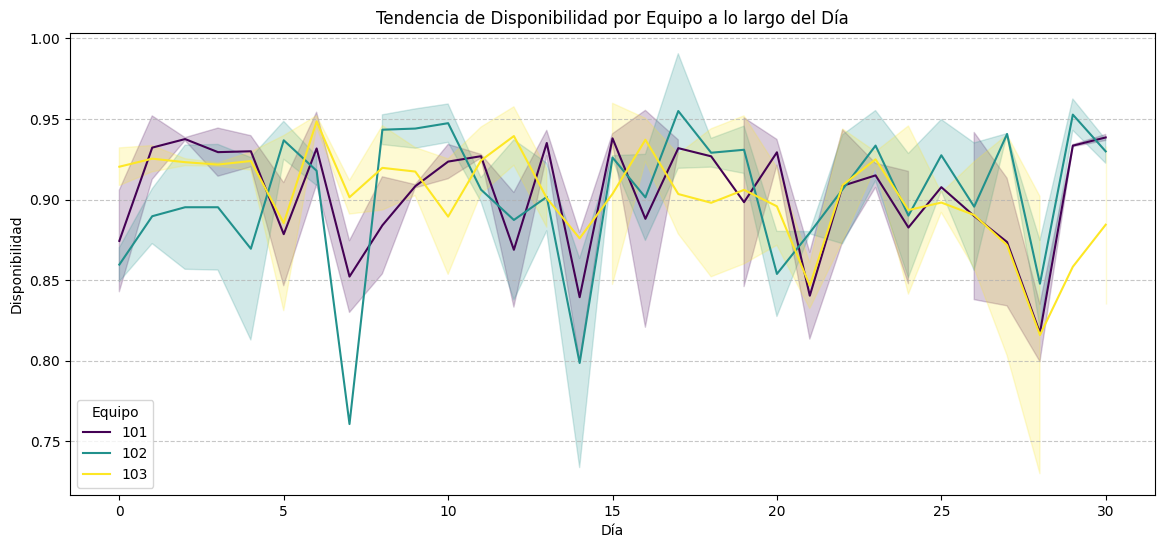

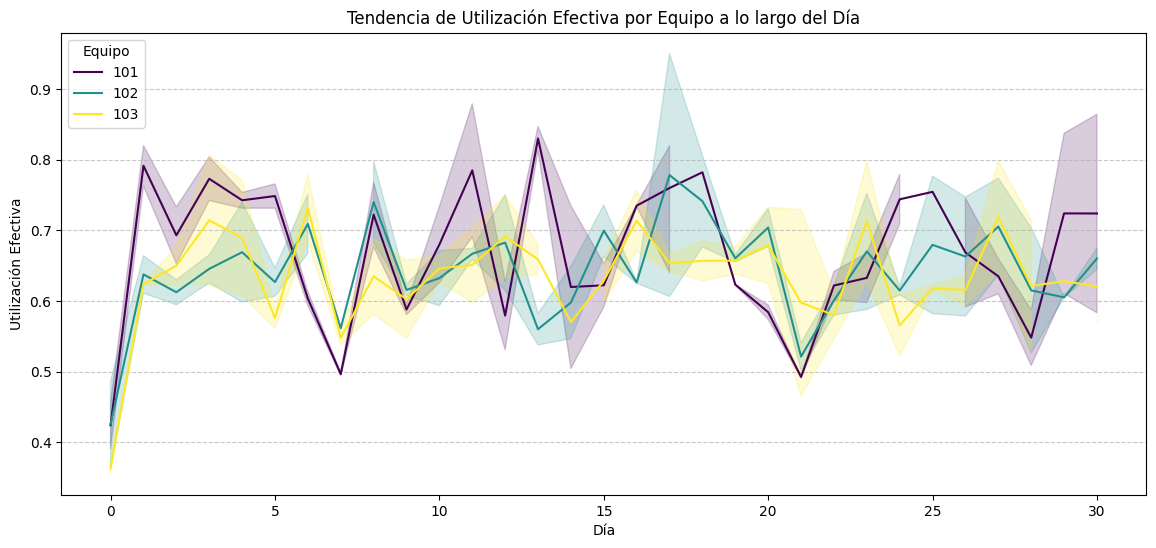


Generating line plots for KPIs over Dia, differentiated by Turno (subplots by Equipo):


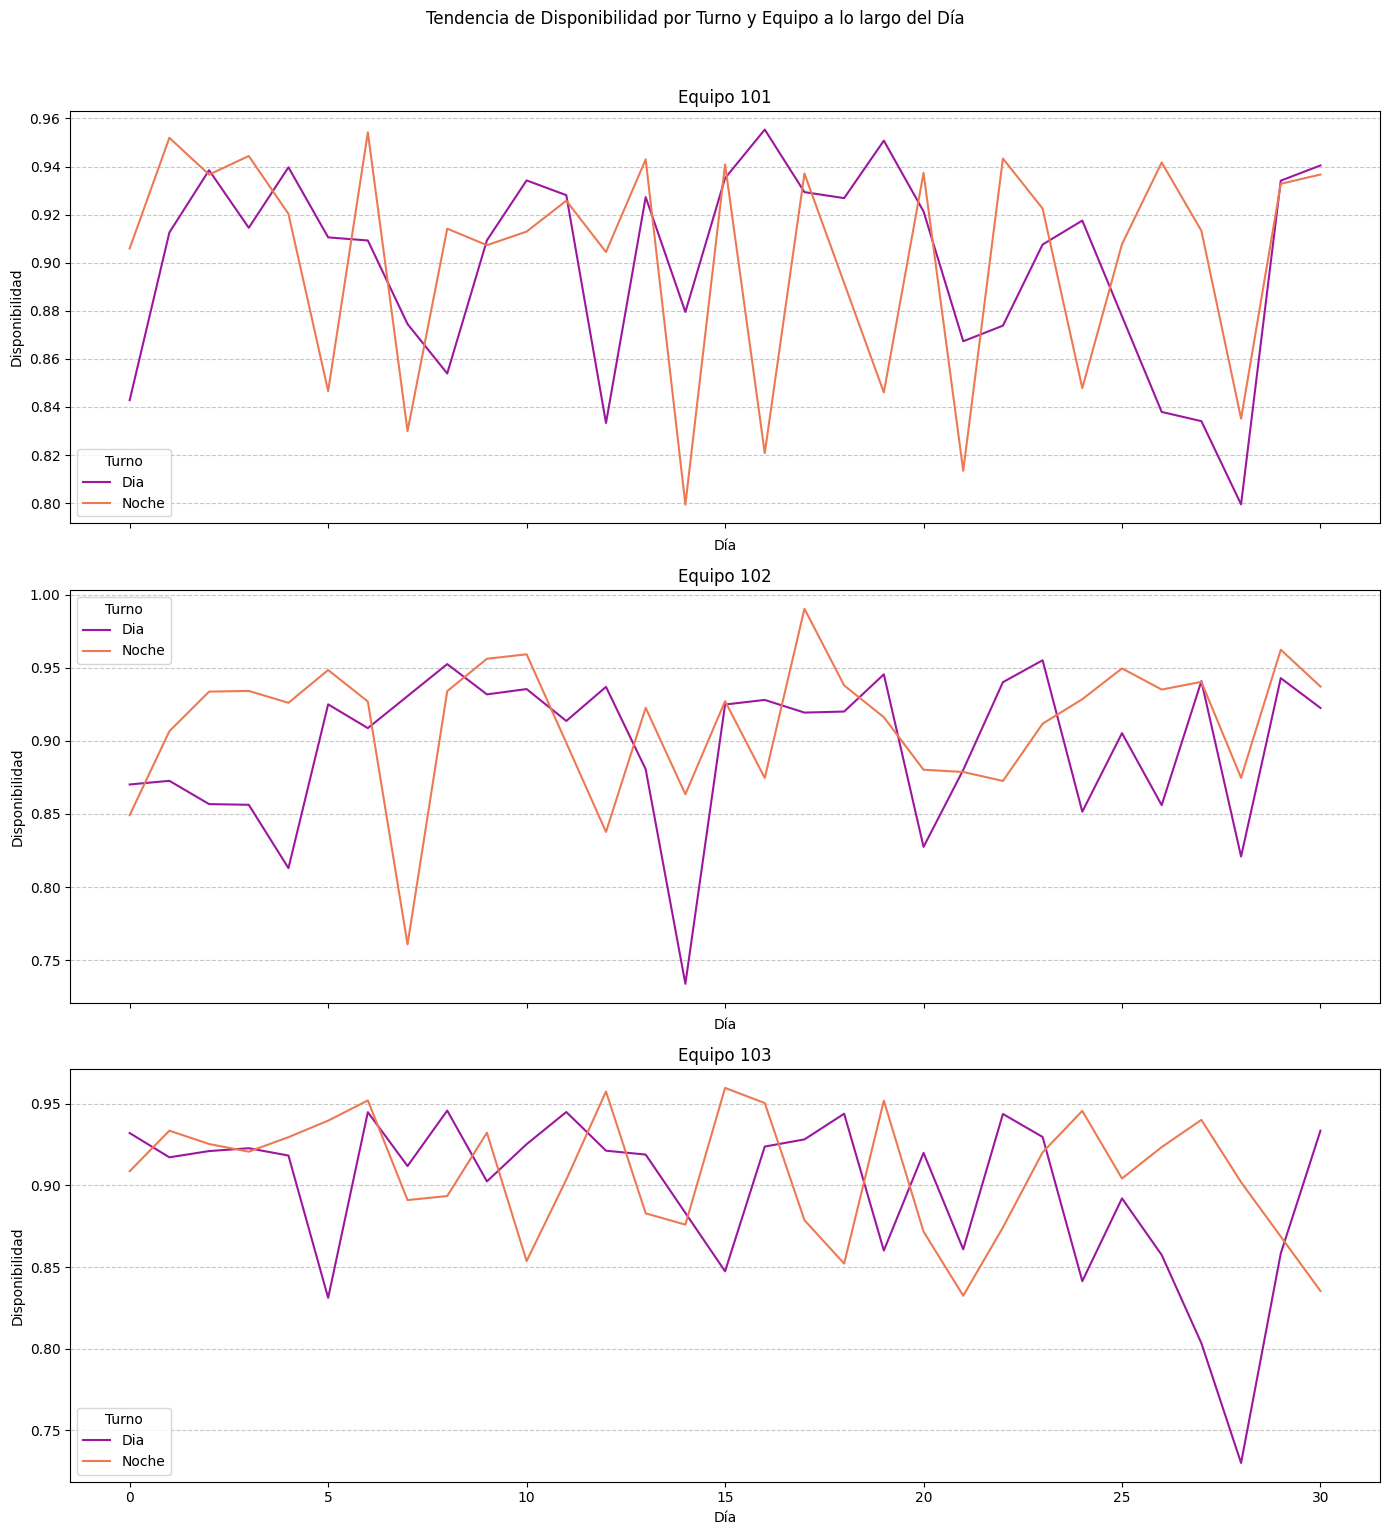

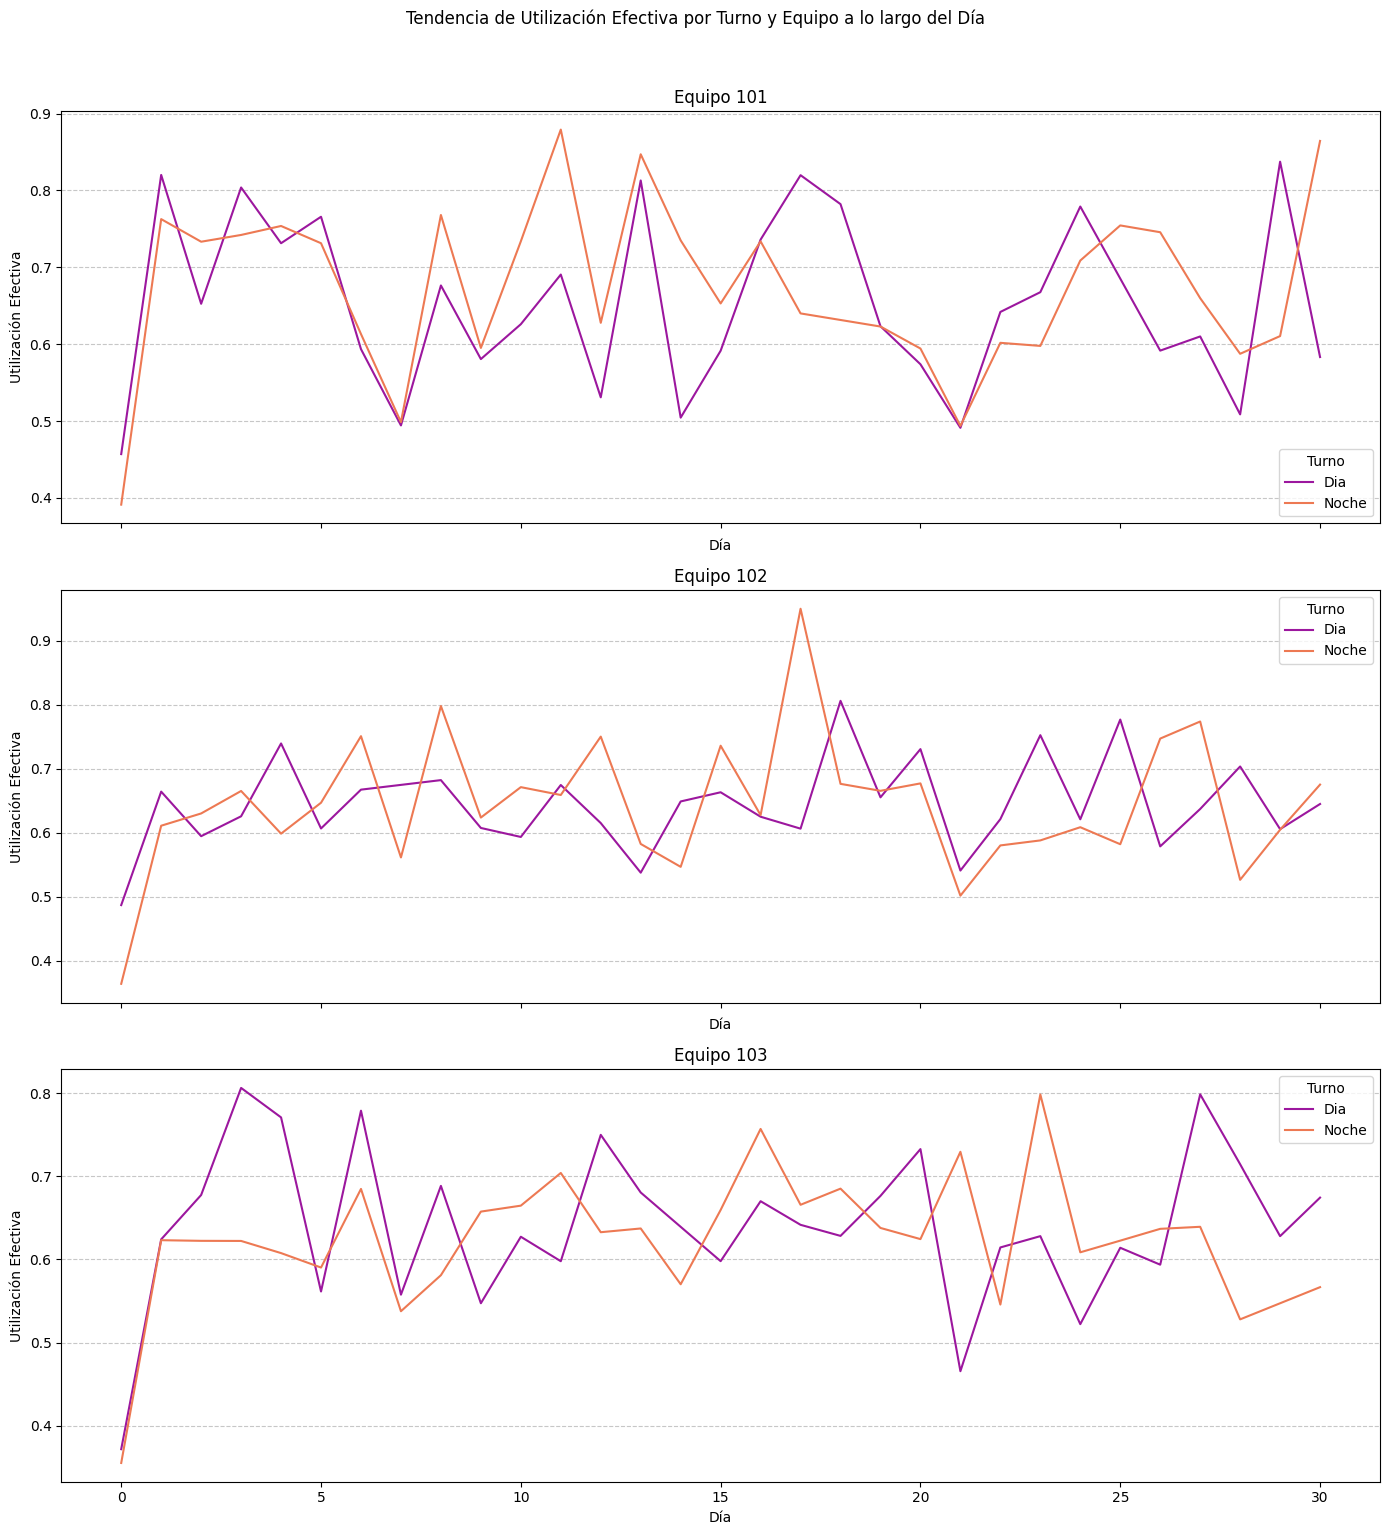

In [ ]:
# 1. and 2. Trend of KPIs over Dia, differentiated by Equipo
print("Generating line plots for KPIs over Dia, differentiated by Equipo:")
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_CAEX, x='Dia', y='Disponibilidad', hue='Equipo', palette='viridis')
plt.title('Tendencia de Disponibilidad por Equipo a lo largo del Día')
plt.xlabel('Día')
plt.ylabel('Disponibilidad')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_CAEX, x='Dia', y='Utilizacion_Efectiva', hue='Equipo', palette='viridis')
plt.title('Tendencia de Utilización Efectiva por Equipo a lo largo del Día')
plt.xlabel('Día')
plt.ylabel('Utilización Efectiva')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Trend of KPIs over Dia, differentiated by Turno (using subplots for each Equipo)
print("\nGenerating line plots for KPIs over Dia, differentiated by Turno (subplots by Equipo):")

# Get unique Equipo values
equipos = df_CAEX['Equipo'].unique()

# Plot Disponibilidad by Turno for each Equipo
fig, axes = plt.subplots(nrows=len(equipos), figsize=(14, len(equipos) * 5))
fig.suptitle('Tendencia de Disponibilidad por Turno y Equipo a lo largo del Día', y=1.02)

for i, equipo in enumerate(equipos):
    sns.lineplot(data=df_CAEX[df_CAEX['Equipo'] == equipo], x='Dia', y='Disponibilidad', hue='Turno', ax=axes[i], palette='plasma')
    axes[i].set_title(f'Equipo {equipo}')
    axes[i].set_xlabel('Día')
    axes[i].set_ylabel('Disponibilidad')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    if i < len(equipos) - 1:
        axes[i].set_xticklabels([]) # Hide x-axis labels for all but the last subplot

plt.tight_layout()
plt.show()

# Plot Utilizacion_Efectiva by Turno for each Equipo
fig, axes = plt.subplots(nrows=len(equipos), figsize=(14, len(equipos) * 5))
fig.suptitle('Tendencia de Utilización Efectiva por Turno y Equipo a lo largo del Día', y=1.02)

for i, equipo in enumerate(equipos):
    sns.lineplot(data=df_CAEX[df_CAEX['Equipo'] == equipo], x='Dia', y='Utilizacion_Efectiva', hue='Turno', ax=axes[i], palette='plasma')
    axes[i].set_title(f'Equipo {equipo}')
    axes[i].set_xlabel('Día')
    axes[i].set_ylabel('Utilización Efectiva')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    if i < len(equipos) - 1:
        axes[i].set_xticklabels([]) # Hide x-axis labels for all but the last subplot

plt.tight_layout()
plt.show()

### Análisis Detallado de Utilización Efectiva y Disponibilidad por Día, Turno y Equipo

Basado en los gráficos de tendencias temporales generados para la Disponibilidad y la Utilización Efectiva, diferenciados por Equipo y Turno:

**Análisis General por Equipo (Gráficos de Tendencia Agregada):**

*   **Disponibilidad por Equipo:** Los gráficos de Disponibilidad agregada por equipo muestran la variabilidad general de este KPI a lo largo del mes para cada uno de los equipos. Se puede observar si algún equipo presenta una disponibilidad consistentemente más baja o más alta que los otros, o si experimentan caídas significativas en días específicos que podrían estar relacionadas con paradas programadas o no programadas. Una menor variabilidad indica una operación más estable en términos de estar disponible para operar.
*   **Utilización Efectiva por Equipo:** De manera similar, los gráficos de Utilización Efectiva por equipo muestran la eficiencia general de uso del tiempo disponible. Se puede comparar qué equipo, en promedio, logra una mayor productividad cuando está operativo. Una mayor variabilidad en la Utilización Efectiva podría sugerir inconsistencias en la operación, la gestión del tiempo o las condiciones de trabajo.

**Análisis Detallado por Equipo y Turno (Gráficos con Subplots):**

La desagregación por turno (`Dia` y `Noche`) dentro de cada equipo permite un análisis más granular:

*   **Comparación de Turnos por Equipo:** Estos gráficos son fundamentales para identificar si existen diferencias sistemáticas en el desempeño entre el turno de día y el turno de noche para un equipo específico.
    *   ¿Un turno consistentemente tiene mayor Disponibilidad que el otro? (Podría indicar diferencias en los procedimientos de inicio/fin de turno, mantenimientos, o asignación de recursos).
    *   ¿Un turno logra una mayor Utilización Efectiva? (Podría estar influenciado por la visibilidad, las condiciones del camino, la supervisión, la fatiga del operador, o la naturaleza de las tareas asignadas a cada turno).
*   **Identificación de Patrones Específicos:** Es posible que se identifiquen patrones que solo se manifiestan en un turno particular. Por ejemplo, caídas recurrentes en la Disponibilidad en el turno de noche para un equipo, o picos de Utilización Efectiva en el turno de día.
*   **Impacto de Factores Externos:** Si bien no se graficaron directamente en estos plots, la variabilidad observada en ciertos días o turnos podría correlacionarse con factores externos como el clima o las condiciones del camino, los cuales están disponibles en la base de datos y podrían explorarse en análisis posteriores.

**Interpretación de las Fluctuaciones:**

Las fluctuaciones en los KPIs a lo largo del tiempo, tanto a nivel de equipo como de turno, son normales en operaciones mineras debido a la naturaleza dinámica del entorno. Sin embargo, las caídas abruptas o los períodos prolongados de bajo desempeño para un equipo o turno específico merecen una investigación más profunda para identificar las causas raíz (ej. problemas mecánicos recurrentes, condiciones operacionales adversas, issues de gestión).

### Resumen Ejecutivo del Análisis de UE y Disponibilidad

El análisis de la **Disponibilidad** y la **Utilización Efectiva** por día, turno y equipo revela que, en promedio, los equipos tienen una alta disponibilidad (alrededor del 90%), pero existe una mayor variabilidad en cuán eficientemente se utiliza ese tiempo disponible (Utilización Efectiva promedio del 65% con mayor dispersión).

Los gráficos de tendencias temporales muestran fluctuaciones diarias en ambos KPIs para todos los equipos. La desagregación por turno (`Dia` y `Noche`) permite identificar posibles diferencias de desempeño entre turnos dentro de cada equipo, sugiriendo que ciertos turnos podrían ser consistentemente más o menos efectivos o disponibles.

Este análisis inicial subraya la importancia de monitorear estos KPIs a nivel granular (equipo y turno) para identificar áreas de mejora operacional y comprender los factores que influyen en la variabilidad del desempeño. Las próximas etapas de análisis, como el clustering, ayudarán a agrupar días/turnos/equipos con patrones de desempeño similares, lo que facilitará una gestión más segmentada y efectiva de la operación.

# 3. Estudio exploratorio de datos disponibles incluyendo las variables antes calculadas.

Generando histogramas para variables numéricas:


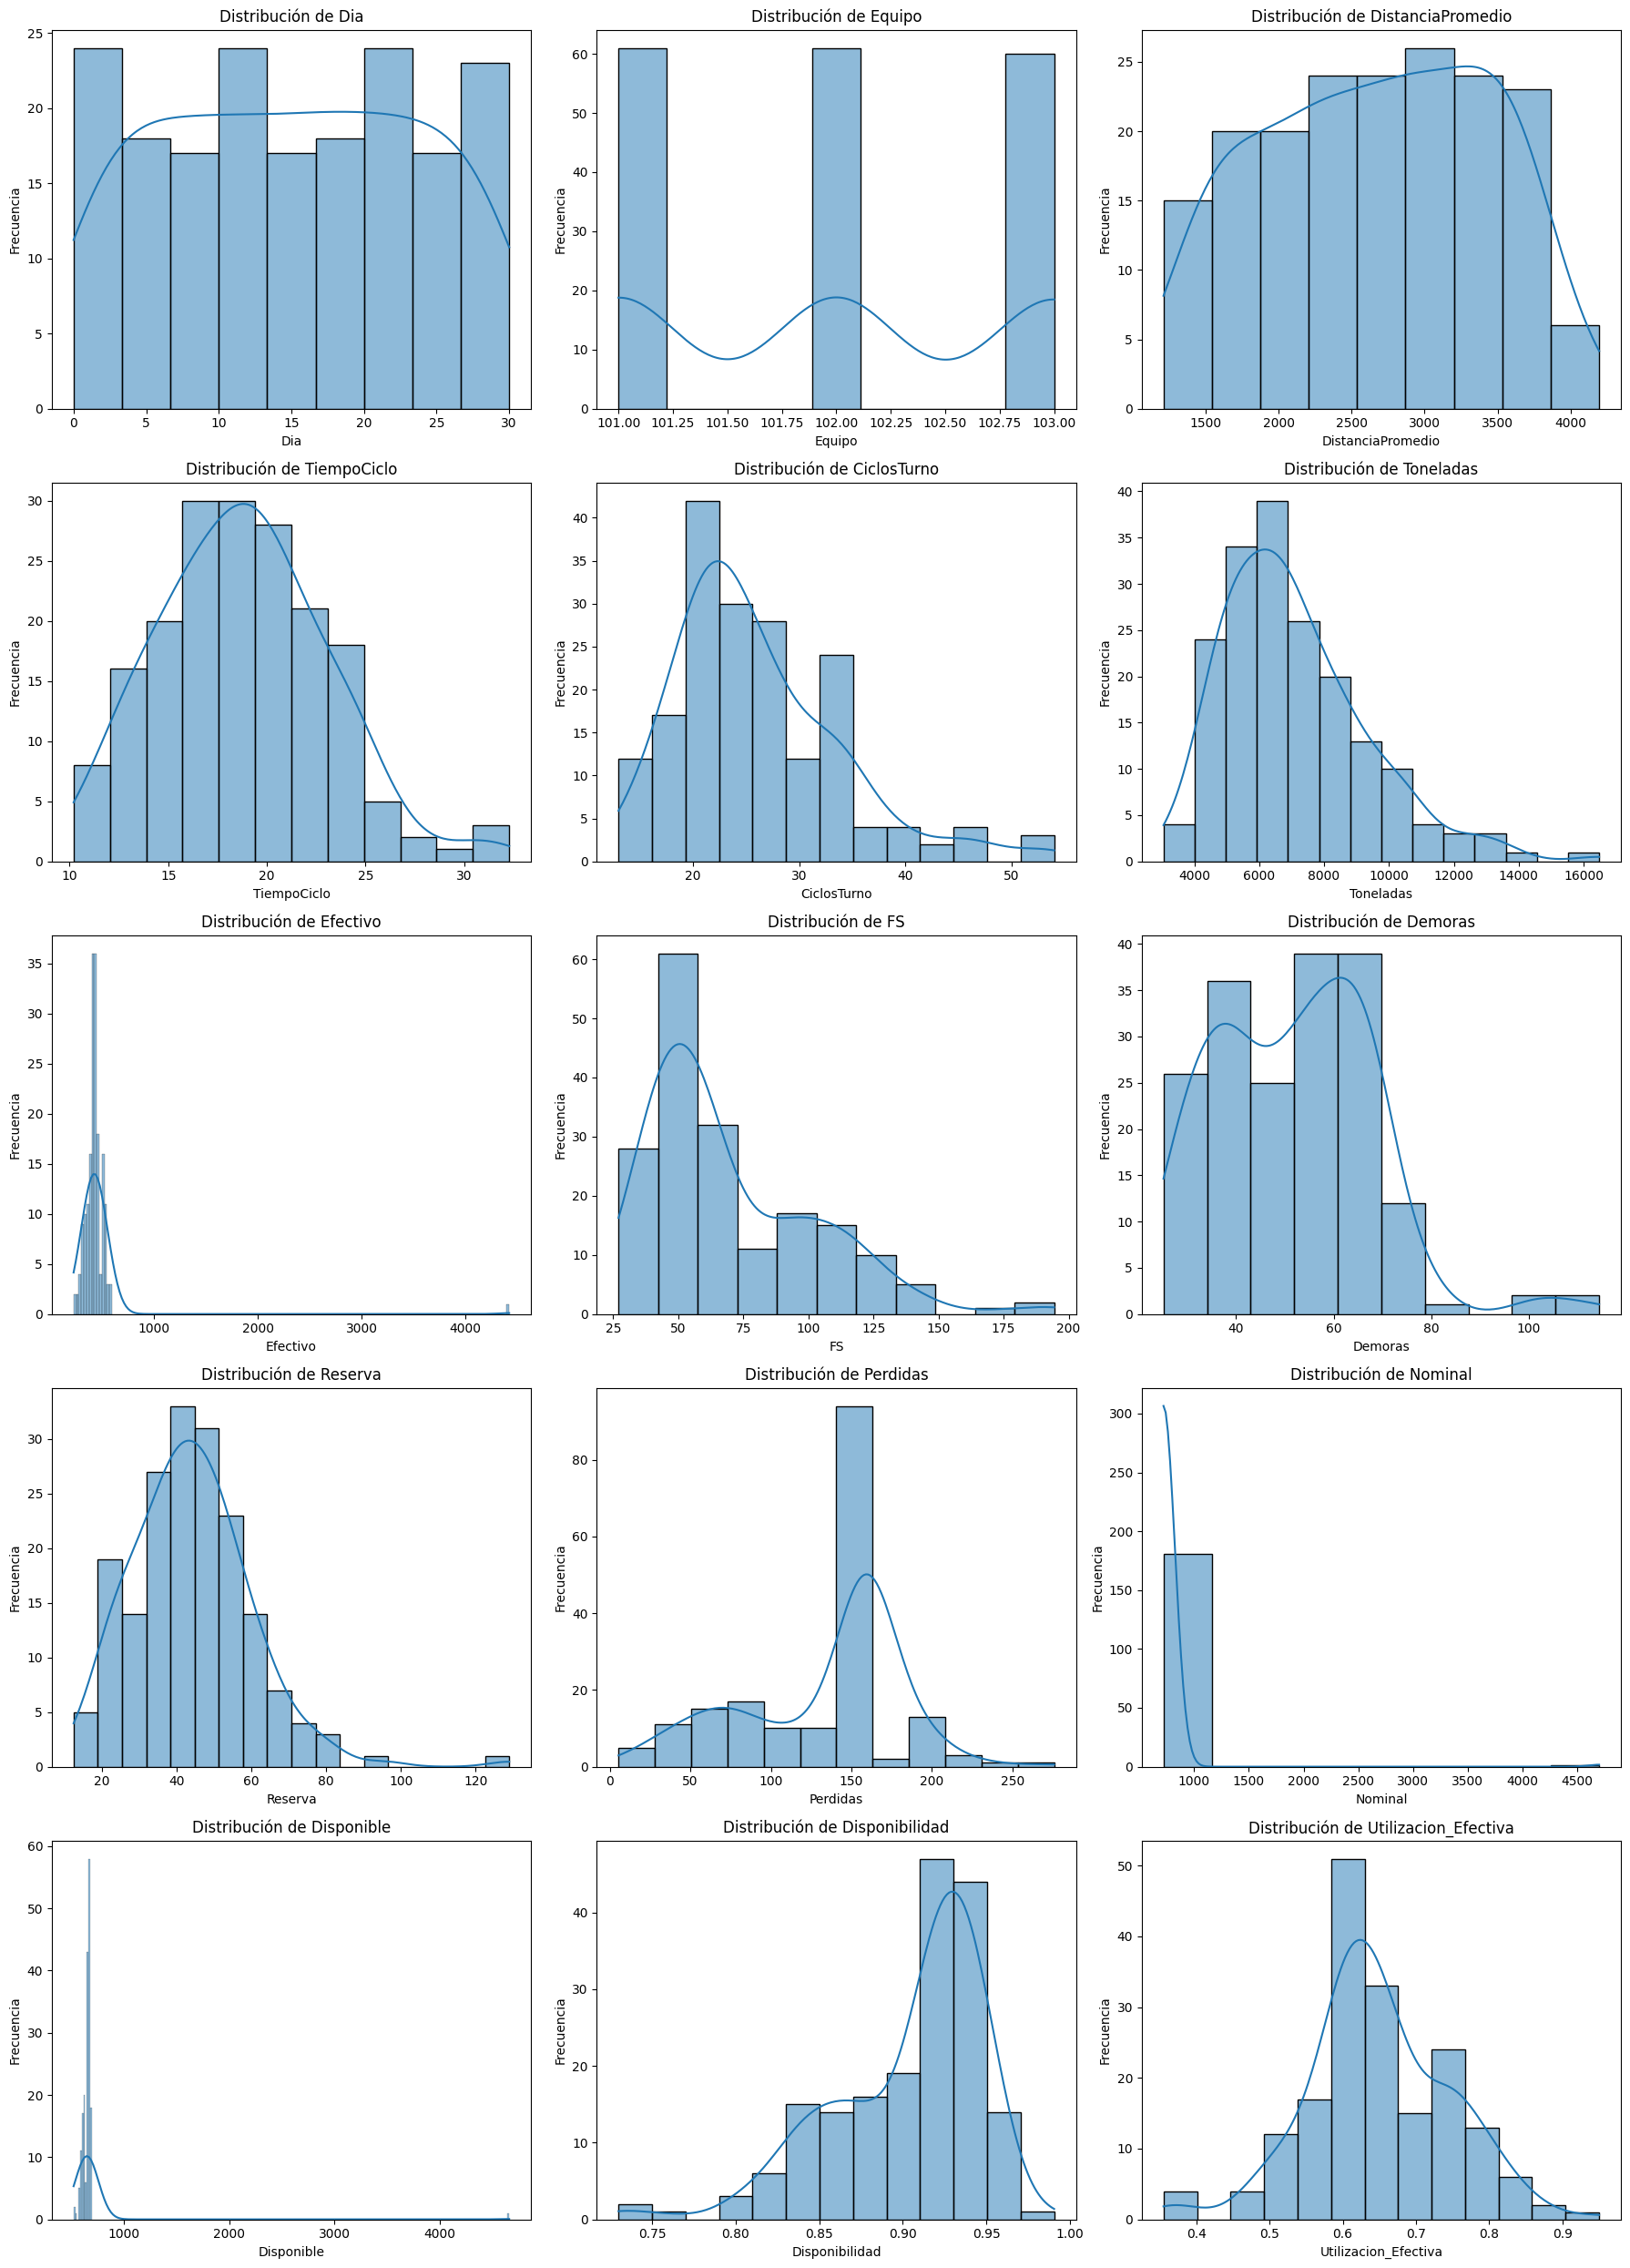

In [ ]:
# --- Estudio Exploratorio de Datos ---

# 3.1 Visualización de distribuciones de variables numéricas

print("Generando histogramas para variables numéricas:")

# Seleccionar solo las columnas numéricas
numeric_cols = df_CAEX.select_dtypes(include=np.number).columns.tolist()

# Ajustar el tamaño de la figura en base al número de plots para evitar superposición
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3 # Organizar en filas de 3

plt.figure(figsize=(18, n_rows * 5)) # Ajustar tamaño de figura según el número de filas

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, 3, i + 1) # Crear subplots
    sns.histplot(data=df_CAEX, x=col, kde=True) # Usar seaborn histplot con KDE para estimación de densidad
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

plt.tight_layout() # Ajustar diseño para prevenir superposición de títulos/etiquetas
plt.show()

Generando boxplots para variables numéricas:


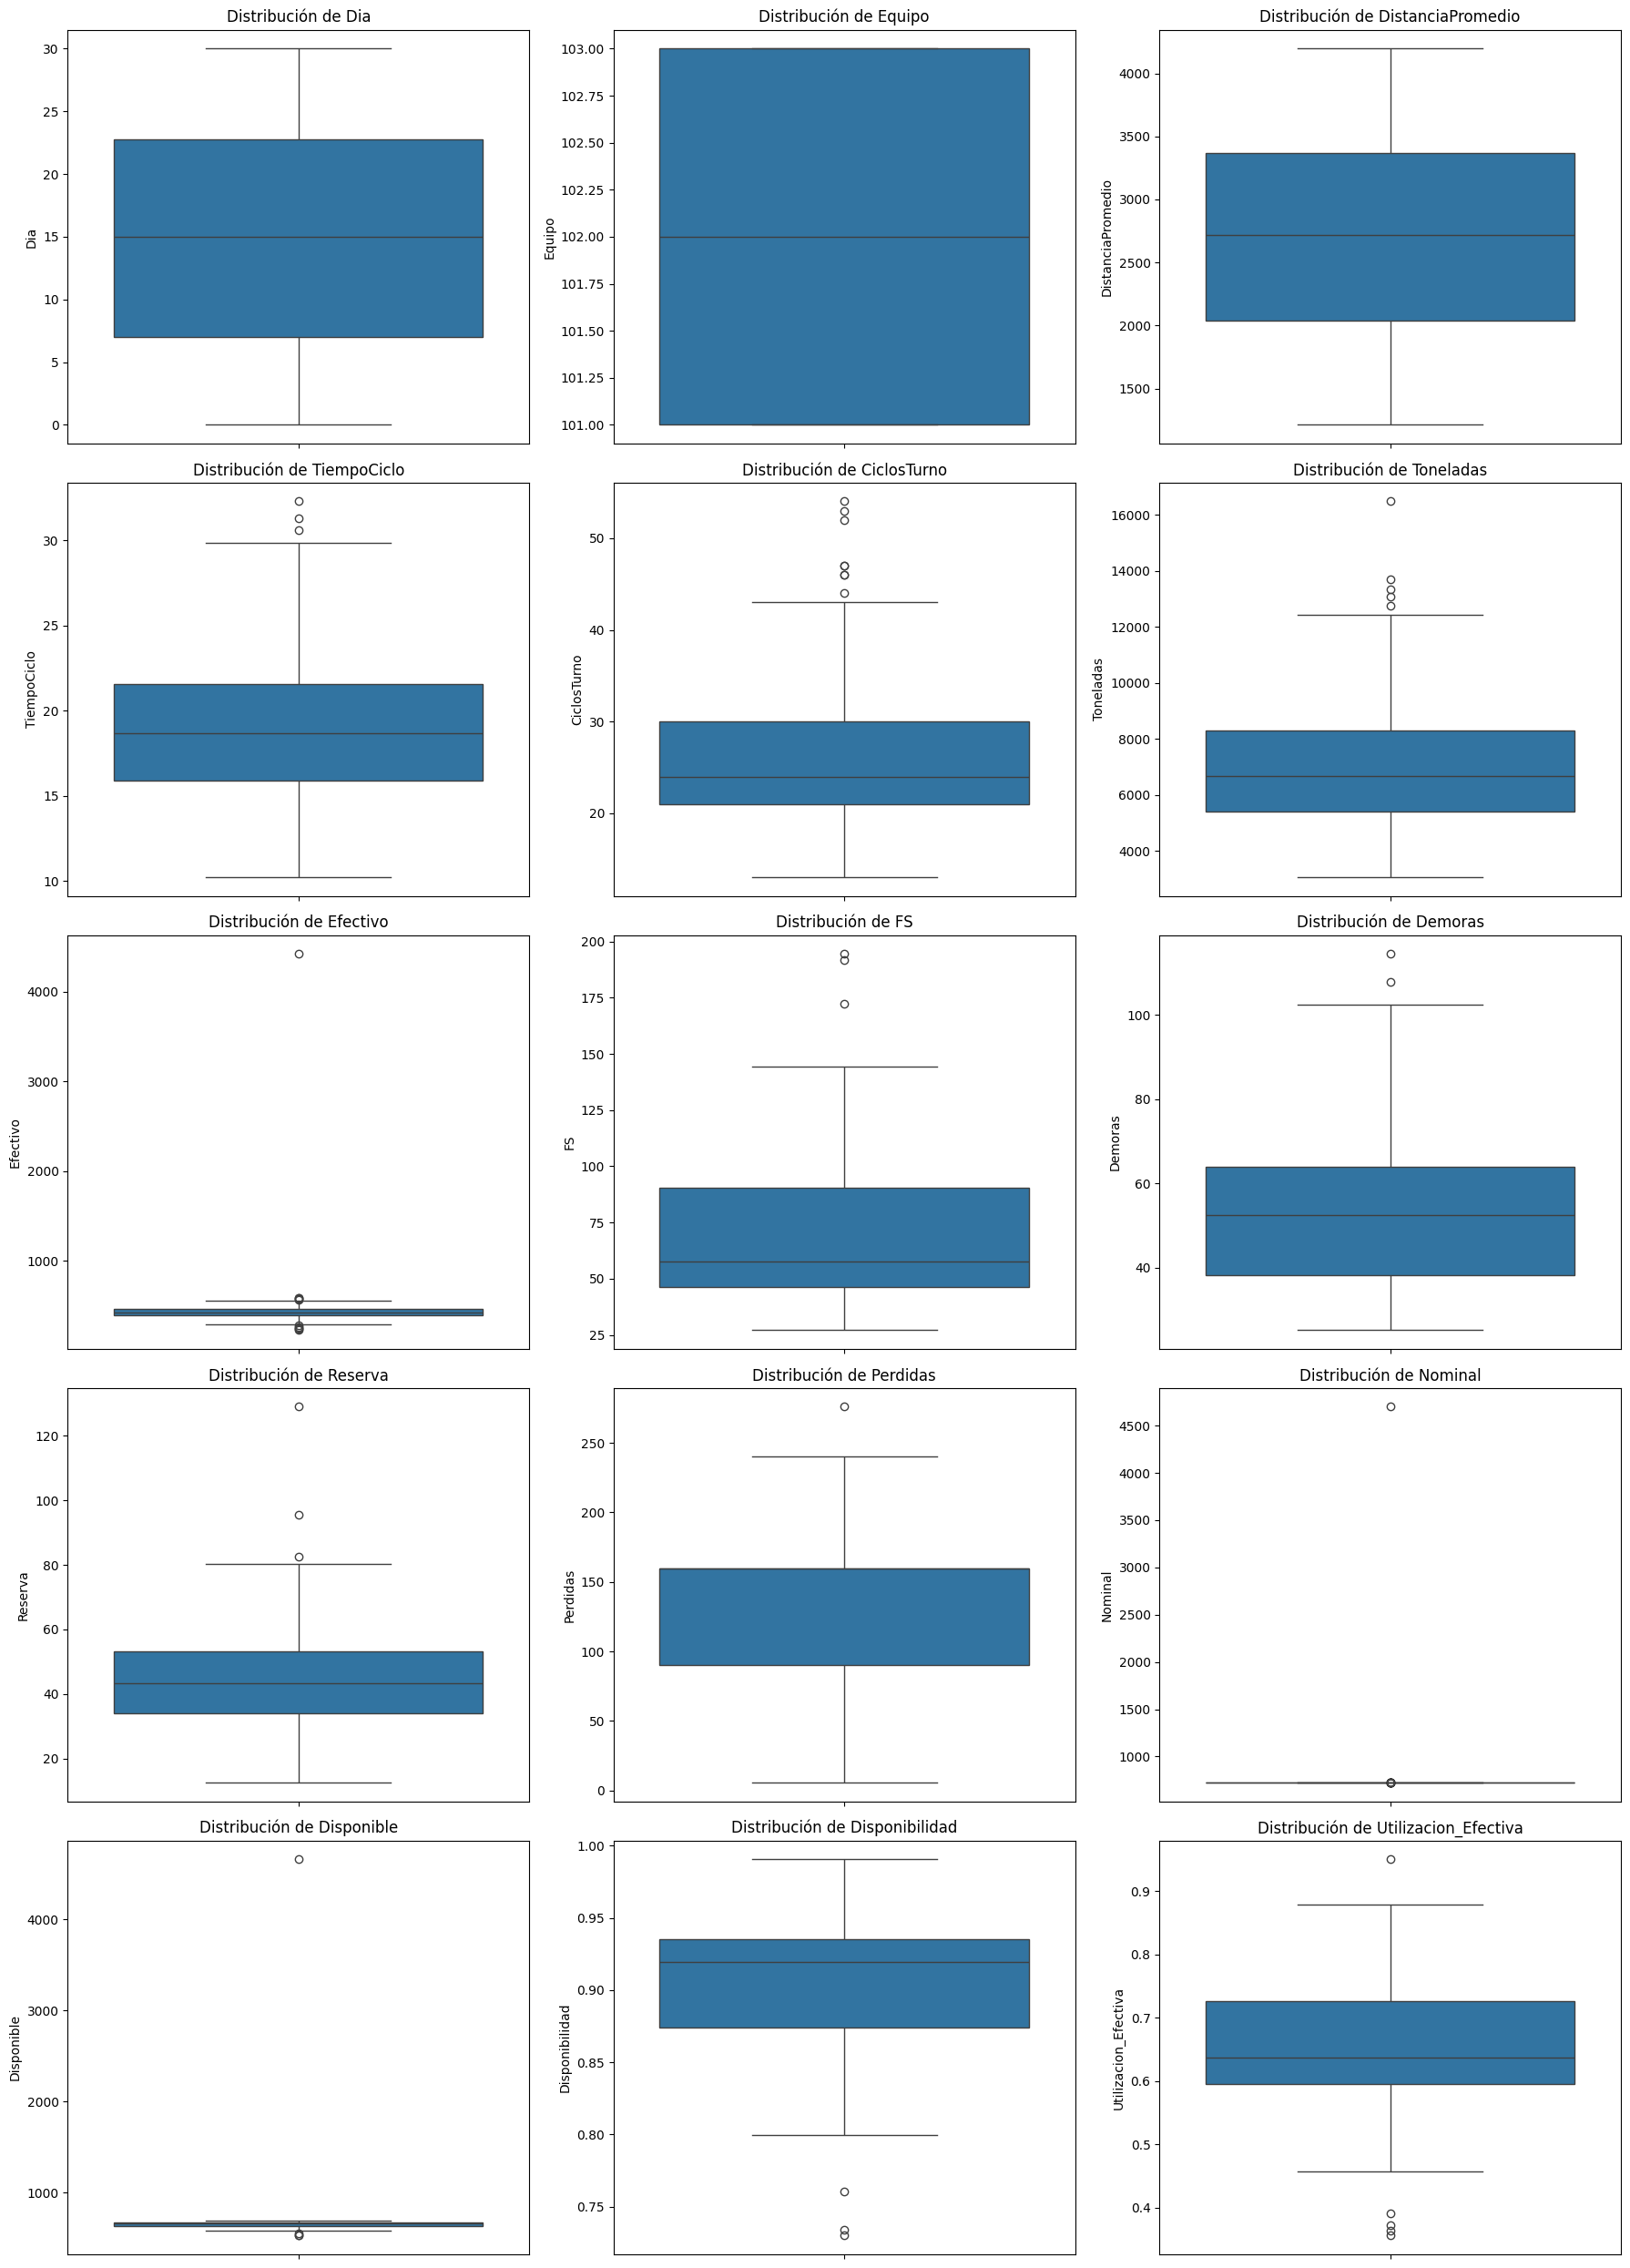


Generando gráficos para variables categóricas:


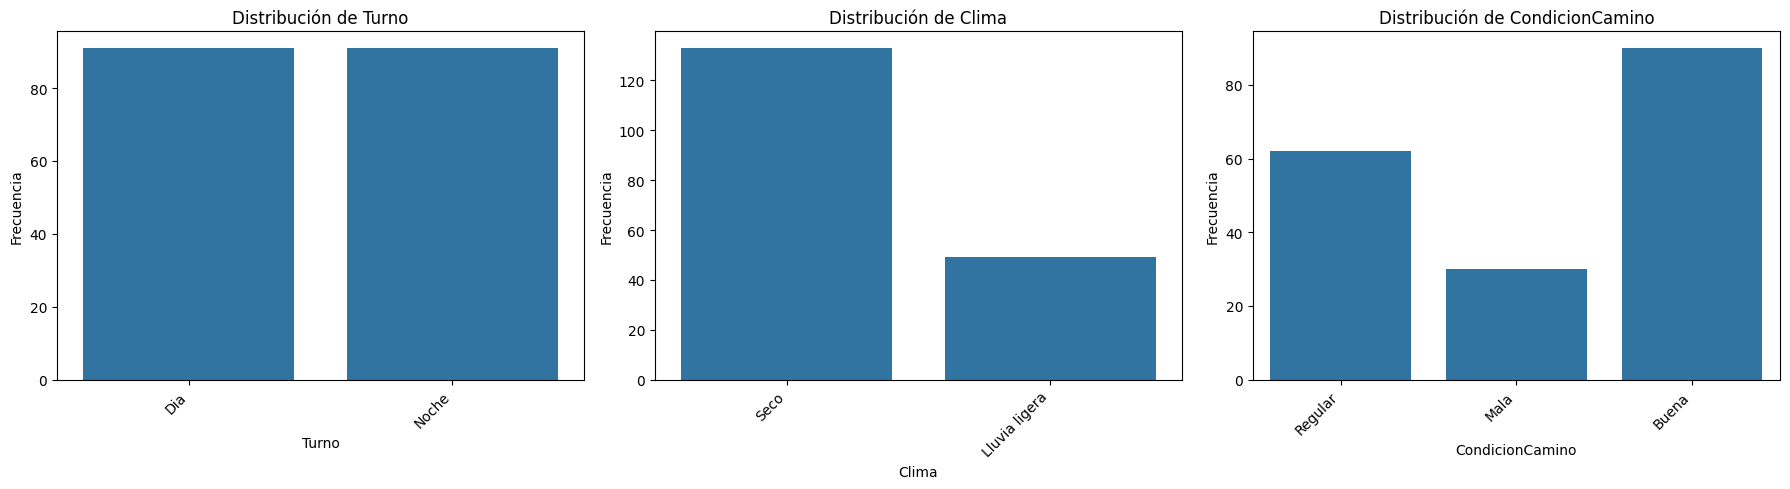

In [ ]:
# Boxplots para variables numéricas
print("Generando boxplots para variables numéricas:")

# Seleccionar solo las columnas numéricas
numeric_cols = df_CAEX.select_dtypes(include=np.number).columns.tolist()

# Excluir columnas que son identificadores si se desea, pero para una vista completa las incluiremos
# Si quisieras excluirlas, podrías usar: [col for col in numeric_cols if col not in ['Dia', 'Equipo']]

# Ajustar el tamaño de la figura en base al número de plots para evitar superposición
n_cols_num = len(numeric_cols)
n_rows_num = (n_cols_num + 2) // 3 # Organizar en filas de 3

plt.figure(figsize=(18, n_rows_num * 5)) # Ajustar tamaño de figura según el número de filas

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows_num, 3, i + 1) # Crear subplots
    sns.boxplot(data=df_CAEX, y=col) # Usar seaborn boxplot
    plt.title(f'Distribución de {col}')
    plt.ylabel(col)
    plt.xlabel('') # No label needed on x-axis for single boxplot

plt.tight_layout() # Ajustar diseño para prevenir superposición de títulos/etiquetas
plt.show()

# Boxplots (o countplots para distribución) para variables categóricas
print("\nGenerando gráficos para variables categóricas:")

# Seleccionar solo las columnas categóricas (object o category dtype)
categorical_cols = df_CAEX.select_dtypes(include=['object', 'category']).columns.tolist()

# Ajustar el tamaño de la figura
n_cols_cat = len(categorical_cols)
plt.figure(figsize=(n_cols_cat * 6, 5)) # Ajustar tamaño de figura

for i, col in enumerate(categorical_cols):
    plt.subplot(1, n_cols_cat, i + 1) # Crear subplots
    sns.countplot(data=df_CAEX, x=col) # Usar seaborn countplot para distribución
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor legibilidad

plt.tight_layout() # Ajustar diseño
plt.show()

Generating scatter plots for Disponibilidad vs numeric variables:


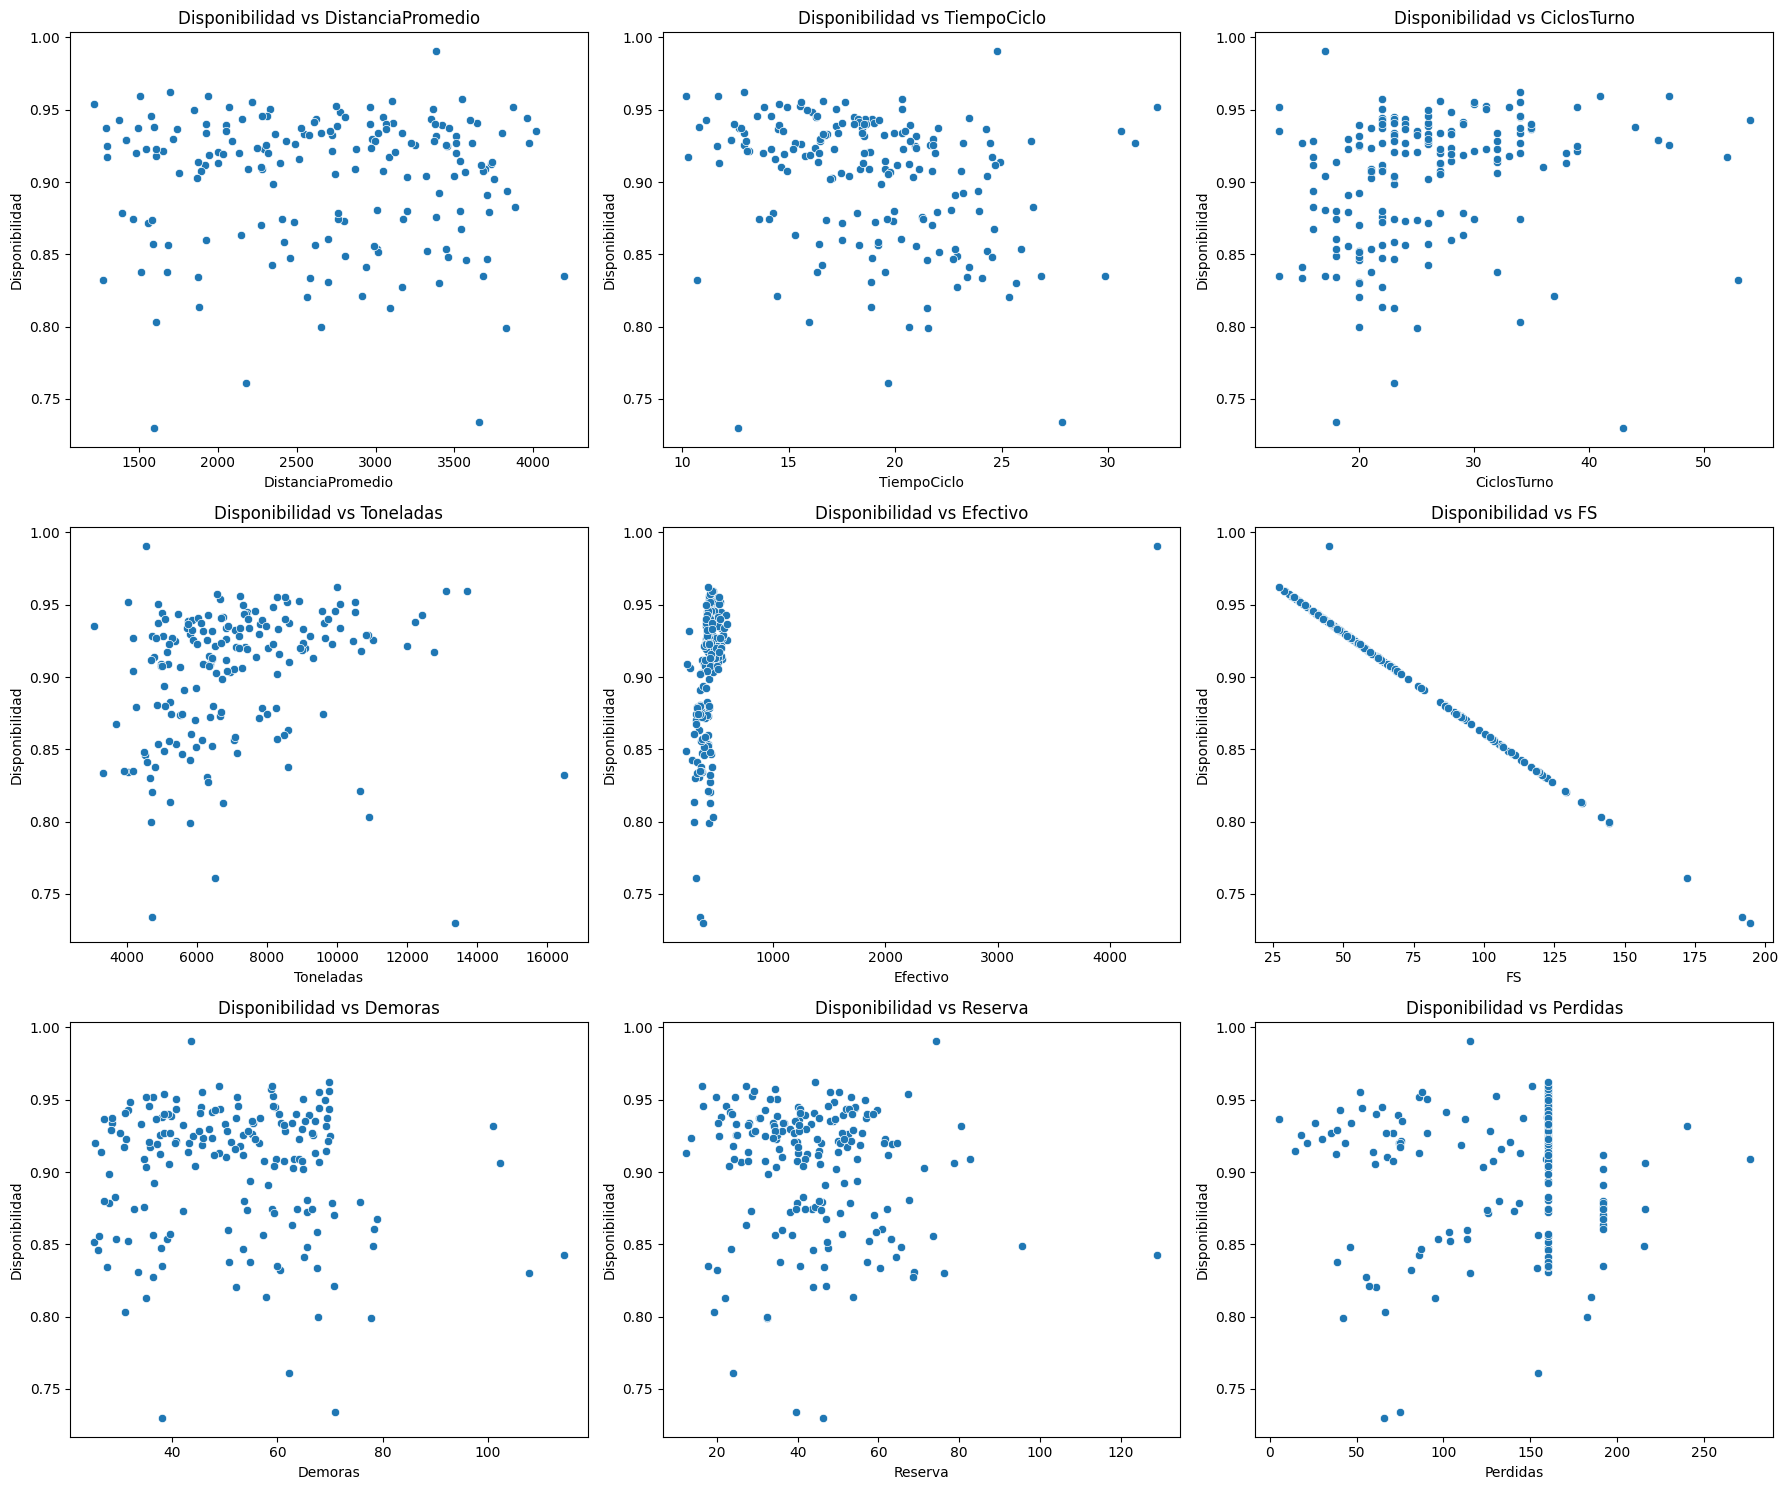


Generating scatter plots for Utilizacion_Efectiva vs numeric variables:


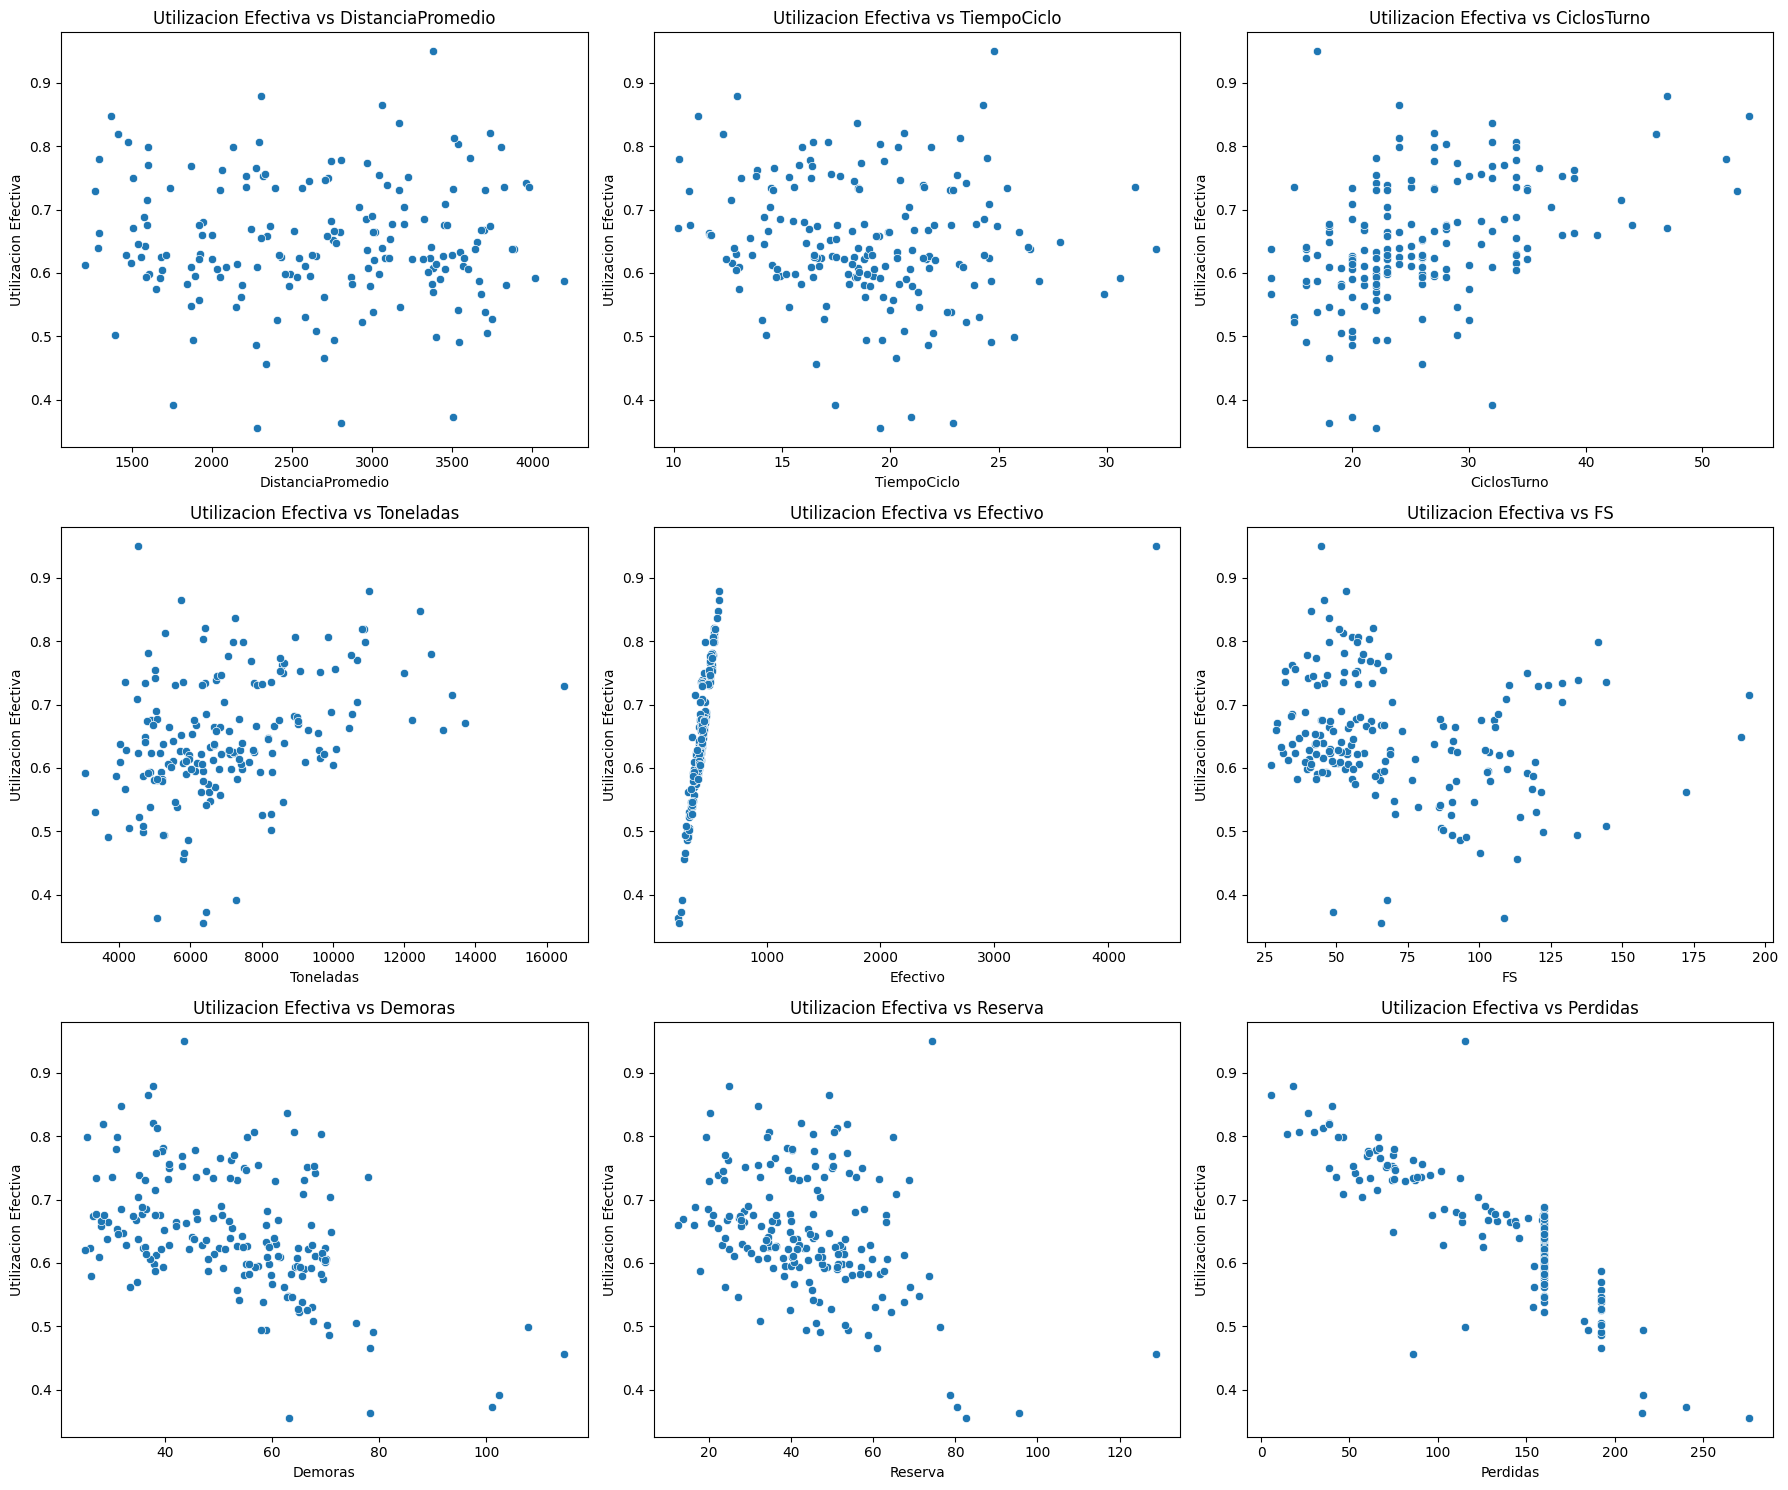

In [ ]:
# Numeric variables for scatter plots
numeric_vars = ['DistanciaPromedio', 'TiempoCiclo', 'CiclosTurno', 'Toneladas', 'Efectivo', 'FS', 'Demoras', 'Reserva', 'Perdidas']
kpi_vars = ['Disponibilidad', 'Utilizacion_Efectiva']

# Scatter plots for Disponibilidad vs numeric variables
print("Generating scatter plots for Disponibilidad vs numeric variables:")
n_cols_num = len(numeric_vars)
n_rows_num = (n_cols_num + 2) // 3 # Arrange in rows of 3

plt.figure(figsize=(18, n_rows_num * 5))

for i, col in enumerate(numeric_vars):
    plt.subplot(n_rows_num, 3, i + 1)
    sns.scatterplot(data=df_CAEX, x=col, y='Disponibilidad')
    plt.title(f'Disponibilidad vs {col}')
    plt.xlabel(col)
    plt.ylabel('Disponibilidad')

plt.tight_layout()
plt.show()

# Scatter plots for Utilizacion_Efectiva vs numeric variables
print("\nGenerating scatter plots for Utilizacion_Efectiva vs numeric variables:")
plt.figure(figsize=(18, n_rows_num * 5))

for i, col in enumerate(numeric_vars):
    plt.subplot(n_rows_num, 3, i + 1)
    sns.scatterplot(data=df_CAEX, x=col, y='Utilizacion_Efectiva')
    plt.title(f'Utilizacion Efectiva vs {col}')
    plt.xlabel(col)
    plt.ylabel('Utilizacion Efectiva')

plt.tight_layout()
plt.show()

In [ ]:
# 1) Copia
df_encoded = df_CAEX_capped.copy()

# 2) Dummies (elige las que existan realmente en tu DF)
cand_cat = ["Equipo","Turno", "Clima", "CondicionCamino"]
cat_cols = [c for c in cand_cat if c in df_encoded.columns]

#3) Pasar a dummies
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, dtype=np.int64)

print("DataFrame after correcting column name and applying one-hot encoding:")
display(df_encoded.head())

DataFrame after correcting column name and applying one-hot encoding:


,Dia,DistanciaPromedio,TiempoCiclo,CiclosTurno,Toneladas,Efectivo,FS,Demoras,Reserva,Perdidas,Equipo_101,Equipo_102,Equipo_103,Turno_Dia,Turno_Noche,Clima_Lluvia ligera,Clima_Seco,CondicionCamino_Buena,CondicionCamino_Mala,CondicionCamino_Regular
0,0,2340,16.56,26.0,5802.8,277.324,113.156,102.76,81.8,86.04,1,0,0,1,0,0,1,0,0,1
1,0,1756,17.45,32.0,7281.8,255.208,67.732,102.36,78.7,216.00,1,0,0,0,1,0,1,0,1,0
2,0,2274,21.75,20.0,5947.6,305.064,93.456,70.68,58.8,192.00,0,1,0,1,0,0,1,0,0,1
3,0,2807,22.92,18.0,5052.5,222.496,108.604,78.24,81.8,215.16,0,1,0,0,1,1,0,0,1,0
4,0,3507,20.98,20.0,6443.3,249.660,48.900,101.04,80.4,240.00,0,0,1,1,0,0,1,0,0,1


In [ ]:
mms = MinMaxScaler()
df_encoded_scaled = mms.fit_transform(df_encoded)
df_encoded_scaled = pd.DataFrame(df_encoded_scaled, columns = df_encoded.columns)
df_encoded_scaled.head()

,Dia,DistanciaPromedio,TiempoCiclo,CiclosTurno,Toneladas,Efectivo,FS,Demoras,Reserva,Perdidas,Equipo_101,Equipo_102,Equipo_103,Turno_Dia,Turno_Noche,Clima_Lluvia ligera,Clima_Seco,CondicionCamino_Buena,CondicionCamino_Mala,CondicionCamino_Regular
0,0.0,0.378224,0.301708,0.382353,0.258266,0.150849,0.665290,1.000000,0.988604,0.298004,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,0.182580,0.343928,0.558824,0.397070,0.090001,0.314326,0.994849,0.944444,0.778271,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.0,0.356114,0.547913,0.205882,0.271855,0.227170,0.513080,0.586917,0.660969,0.689579,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.534673,0.603416,0.147059,0.187850,0.000000,0.630119,0.684265,0.988604,0.775166,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.769179,0.511385,0.205882,0.318377,0.074736,0.168822,0.977852,0.968661,0.866962,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


# 4. Utilizar los métodos no supervisados kmeans y DBSCAN para identificar patrones operacionales entre los equipos.

# 5. Realizar un análisis de componentes principales (PCA)

# 12 Referencias

1.

2.

3.

# 13 Descarga HTML

In [ ]:
import nbformat

src_path = "/content/drive/MyDrive/2025/Análisis de Datos/Proyecto/Hitos/Hito 3/Hito_3.ipynb"

nb = nbformat.read(src_path, as_version=4)
print("OK. nbformat:", nb.nbformat, ".", nb.nbformat_minor, " | celdas:", len(nb.cells))

OK. nbformat: 4 . 0  | celdas: 48


In [ ]:
# 1) Instalar versiones compatibles
!pip -q install "nbconvert==7.16.4" "mistune==3.0.2" "jinja2==3.1.4" \
                "pygments==2.18.0" "jupyterlab-pygments==0.3.0" \
                "beautifulsoup4" "tinycss2" "bleach" "defusedxml"

In [ ]:
import nbformat
from nbconvert import HTMLExporter

nb_path = "/content/drive/MyDrive/2025/Análisis de Datos/Proyecto/Hitos/Hito 3/Hito_3.ipynb"

# Leer el notebook como nbformat
nb = nbformat.read(open(nb_path), as_version=4)

# Crear exportador HTML (plantilla básica)
html_exporter = HTMLExporter()
html_exporter.exclude_input = False  # True para ocultar el código
(body, resources) = html_exporter.from_notebook_node(nb)

# Guardar el HTML
with open("/content/Hito_3.html", "w", encoding="utf-8") as f:
    f.write(body)

print("HTML generado en /content/Hito_3.html")

HTML generado en /content/Hito_3.html


In [ ]:
html_exporter.exclude_input = True